In [8]:
import os

import matplotlib.pyplot as plt
import numpy as np
import gempy as gp
import matplotlib.pyplot as plt
import pandas as pd
import gempy_viewer as gpv
import HelperMethods as helper

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree

path_to_data = r"C:\Users\mrcon\OneDrive\Data B\School\GP2\Internship\Mineye\GIS\Tharsis\Output\formationinputpoints.csv"
path_to_orientations = r"C:\Users\mrcon\OneDrive\Data B\School\GP2\Internship\Mineye\GIS\Tharsis\Output\orientations.csv"
path_to_topography = r"C:\Users\mrcon\OneDrive\Data B\School\GP2\Internship\Mineye\GIS\Tharsis\Output\topo.tif"
path_to_topography_cleaned = r"C:\Users\mrcon\OneDrive\Data B\School\GP2\Internship\Mineye\GIS\Tharsis\Output\topo_cleaned.tif"

Setting Backend To: AvailableBackends.numpy


In [5]:
points_df = pd.read_csv(path_to_data, encoding='latin1', engine='python')
sampled_points_df       = sampling(points_df,plotting=False)
# sampled_points_df = sampled_points_df[sampled_points_df['formation'].isin(['Tournaisian Plutonites', 'Upper Carboniferous Volcanics'])].reset_index(drop=True)

Formation: Upper Devonian Siliciclastics, Points: 18, Spacing: 2500.00
Formation: Visean Shales, Points: 16, Spacing: 2357.02
Formation: Tournaisian Plutonites, Points: 296, Spacing: 10137.94
Formation: Upper Carboniferous Volcanics, Points: 45, Spacing: 3952.85
Formation: Mid Carboniferous Shales, Points: 13, Spacing: 2124.59
-------------------
Formation: Upper Devonian Siliciclastics, Points left: 3
Formation: Visean Shales, Points left: 3
Formation: Tournaisian Plutonites, Points left: 5
Formation: Upper Carboniferous Volcanics, Points left: 6
Formation: Mid Carboniferous Shales, Points left: 2


In [6]:
orientations_df = pd.read_csv(path_to_orientations, encoding='latin1', engine='python')
# orientations_df = orientations_df[orientations_df['formation'].isin(['Tournaisian Plutonites', 'Upper Carboniferous Volcanics'])].reset_index(drop=True)

In [281]:
# Add volcanic formation orientations around the blob
orange_one_orientations = [
    {'X': -703766, 'Y': 4548057, 'Z': 393, 'azimuth': 8 , 'dip': 80, 'polarity': 1, 'formation': 'Upper Carboniferous Volcanics', 'formation_id':503 },
    {'X': -702385, 'Y': 4548338, 'Z': 339, 'azimuth': 17, 'dip': 80, 'polarity': 1, 'formation': 'Upper Carboniferous Volcanics', 'formation_id':459 },
    {'X': -701112, 'Y': 4548706, 'Z': 372, 'azimuth': 33, 'dip': 80, 'polarity': 1, 'formation': 'Upper Carboniferous Volcanics', 'formation_id':462 },
    {'X': -704771, 'Y': 4549022, 'Z': 414, 'azimuth': 180, 'dip': 80, 'polarity': 1, 'formation': 'Upper Carboniferous Volcanics', 'formation_id':910 },
    {'X': -703295, 'Y': 4549066, 'Z': 336, 'azimuth': 180, 'dip': 80, 'polarity': 1, 'formation': 'Upper Carboniferous Volcanics', 'formation_id':911 },
    {'X': -701111, 'Y': 4549155, 'Z': 508, 'azimuth': 180, 'dip': 80, 'polarity': 1, 'formation': 'Upper Carboniferous Volcanics', 'formation_id':912 },
    {'X': -699852, 'Y': 4549196, 'Z': 351, 'azimuth': 180, 'dip': 80, 'polarity': 1, 'formation': 'Upper Carboniferous Volcanics', 'formation_id':913 },
]

# Add inner points in volcanic formations
orange_one_points = [
    {'X': -704388, 'Y': 4548761, 'Z': 424, 'formation': 'Upper Carboniferous Volcanics', 'formation_id':1 },
    {'X': -702784, 'Y': 4548667, 'Z': 417, 'formation': 'Upper Carboniferous Volcanics', 'formation_id':2 },
    {'X': -701587, 'Y': 4548986, 'Z': 415, 'formation': 'Upper Carboniferous Volcanics', 'formation_id':3 },
    {'X': -700196, 'Y': 4549062, 'Z': 368, 'formation': 'Upper Carboniferous Volcanics', 'formation_id':4 },
]

orange_two_orientations = [
    {'X': -702240, 'Y': 4530674, 'Z': 339, 'azimuth':  178, 'dip': 80, 'polarity': 1, 'formation': 'Upper Carboniferous Volcanics', 'formation_id':204},
    {'X': -700747, 'Y': 4530651, 'Z': 351, 'azimuth':  175, 'dip': 80, 'polarity': 1, 'formation': 'Upper Carboniferous Volcanics', 'formation_id':201},
    {'X': -698793, 'Y': 4530772, 'Z': 392, 'azimuth':  152, 'dip': 80, 'polarity': 1, 'formation': 'Upper Carboniferous Volcanics', 'formation_id':197},
    {'X': -696319, 'Y': 4531002, 'Z': 265, 'azimuth':  177, 'dip': 80, 'polarity': 1, 'formation': 'Upper Carboniferous Volcanics', 'formation_id':192},
    {'X': -694922, 'Y': 4530496, 'Z': 232, 'azimuth':  360-20,  'dip': 80, 'polarity': 1, 'formation': 'Upper Carboniferous Volcanics', 'formation_id':496},
    {'X': -696661, 'Y': 4529687, 'Z': 268, 'azimuth':  360-29,  'dip': 80, 'polarity': 1, 'formation': 'Upper Carboniferous Volcanics', 'formation_id':492},
    {'X': -698831, 'Y': 4528912, 'Z': 289, 'azimuth':  360-90,  'dip': 80, 'polarity': 1, 'formation': 'Upper Carboniferous Volcanics', 'formation_id':499},
    {'X': -699499, 'Y': 4528693, 'Z': 279, 'azimuth':  0,  'dip': 80, 'polarity': 1, 'formation': 'Upper Carboniferous Volcanics', 'formation_id':900},
    {'X': -701666, 'Y': 4528613, 'Z': 329, 'azimuth':  0,  'dip': 80, 'polarity': 1, 'formation': 'Upper Carboniferous Volcanics', 'formation_id':901},
    {'X': -703104, 'Y': 4528571, 'Z': 277, 'azimuth':  0,  'dip': 80, 'polarity': 1, 'formation': 'Upper Carboniferous Volcanics', 'formation_id':902},
    {'X': -706503, 'Y': 4528469, 'Z': 293, 'azimuth':  0,  'dip': 80, 'polarity': 1, 'formation': 'Upper Carboniferous Volcanics', 'formation_id':903},
    {'X': -705602, 'Y': 4530718, 'Z': 297, 'azimuth':  142,  'dip': 80, 'polarity': 1, 'formation': 'Upper Carboniferous Volcanics', 'formation_id':904},
]

orange_two_points = [
    {'X': -705633, 'Y': 4529553, 'Z': 309, 'formation': 'Upper Carboniferous Volcanics', 'formation_id':5 },
    {'X': -703786, 'Y': 4530306, 'Z': 372, 'formation': 'Upper Carboniferous Volcanics', 'formation_id':6 },
    {'X': -701928, 'Y': 4529213, 'Z': 299, 'formation': 'Upper Carboniferous Volcanics', 'formation_id':7 },
    {'X': -699932, 'Y': 4530083, 'Z': 399, 'formation': 'Upper Carboniferous Volcanics', 'formation_id':8 },
    {'X': -697469, 'Y': 4530115, 'Z': 337, 'formation': 'Upper Carboniferous Volcanics', 'formation_id':9 },
    {'X': -695144, 'Y': 4530816, 'Z': 254, 'formation': 'Upper Carboniferous Volcanics', 'formation_id':10 },
]

purple_one_orientations = [
    {'X': -704875, 'Y': 4547579, 'Z': 421, 'azimuth': 360-130, 'dip': -80, 'polarity': 1, 'formation': 'Tournaisian Plutonites', 'formation_id': 239},
    {'X': -704083, 'Y': 4546109, 'Z': 456, 'azimuth': 360-82 , 'dip': -80, 'polarity': 1, 'formation': 'Tournaisian Plutonites', 'formation_id': 243},
    # {'X': -705344, 'Y': 4545762, 'Z': 458, 'azimuth': 360-8  , 'dip': 80, 'polarity': 1, 'formation': 'Tournaisian Plutonites', 'formation_id': 246},
    # {'X': -705294, 'Y': 4545407, 'Z': 417, 'azimuth': 360-169, 'dip': 80, 'polarity': 1, 'formation': 'Tournaisian Plutonites', 'formation_id': 247},
    {'X': -703527, 'Y': 4545376, 'Z': 399, 'azimuth': 155,     'dip': -80, 'polarity': 1, 'formation': 'Tournaisian Plutonites', 'formation_id': 250},
    {'X': -702201, 'Y': 4545068, 'Z': 373, 'azimuth': 360-170, 'dip': -80, 'polarity': 1, 'formation': 'Tournaisian Plutonites', 'formation_id': 253},
    {'X': -702590, 'Y': 4543987, 'Z': 355, 'azimuth': 360-120, 'dip': -80, 'polarity': 1, 'formation': 'Tournaisian Plutonites', 'formation_id': 256},
    {'X': -701976, 'Y': 4542406, 'Z': 371, 'azimuth': 174,     'dip': -80, 'polarity': 1, 'formation': 'Tournaisian Plutonites', 'formation_id': 260},
    {'X': -699648, 'Y': 4544262, 'Z': 271, 'azimuth': 180-175, 'dip': -80, 'polarity': 1, 'formation': 'Tournaisian Plutonites', 'formation_id': 118},
    {'X': -695279, 'Y': 4543351, 'Z': 215, 'azimuth': 165,     'dip': -80, 'polarity': 1, 'formation': 'Tournaisian Plutonites', 'formation_id': 472},
    {'X': -692429, 'Y': 4541732, 'Z': 219, 'azimuth': 360-130, 'dip': -80, 'polarity': 1, 'formation': 'Tournaisian Plutonites', 'formation_id': 280},
    {'X': -688958, 'Y': 4540604, 'Z': 287, 'azimuth': 180,     'dip': -80, 'polarity': 1, 'formation': 'Tournaisian Plutonites', 'formation_id': 288},
    # {'X': -686600, 'Y': 4540323, 'Z': 357, 'azimuth': 360-78,'dip': 80, 'polarity': 1, 'formation': 'Tournaisian Plutonites', 'formation_id': 295},
    {'X': -687674, 'Y': 4537940, 'Z': 317, 'azimuth': 360-28,  'dip': -80, 'polarity': 1, 'formation': 'Tournaisian Plutonites', 'formation_id': 304},
    {'X': -693327, 'Y': 4538250, 'Z': 320, 'azimuth': 360-20,  'dip': -80, 'polarity': 1, 'formation': 'Tournaisian Plutonites', 'formation_id': 140},
    {'X': -695596, 'Y': 4536354, 'Z': 311, 'azimuth': 360-125, 'dip': -80, 'polarity': 1, 'formation': 'Tournaisian Plutonites', 'formation_id': 147},
    {'X': -692417, 'Y': 4534570, 'Z': 344, 'azimuth': 360-125, 'dip': -80, 'polarity': 1, 'formation': 'Tournaisian Plutonites', 'formation_id': 156},
    # {'X': -692861, 'Y': 4532105, 'Z': 271, 'azimuth': 1,       'dip': 80, 'polarity': 1, 'formation': 'Tournaisian Plutonites', 'formation_id': 66},
    # {'X': -695835, 'Y': 4533462, 'Z': 265, 'azimuth': 360-45,  'dip': 80, 'polarity': 1, 'formation': 'Tournaisian Plutonites', 'formation_id': 61},
    # {'X': -698477, 'Y': 4533923, 'Z': 276, 'azimuth': 360-136, 'dip': 80, 'polarity': 1, 'formation': 'Tournaisian Plutonites', 'formation_id': 180},
    # {'X': -695514, 'Y': 4532326, 'Z': 221, 'azimuth': 360-141, 'dip': 80, 'polarity': 1, 'formation': 'Tournaisian Plutonites', 'formation_id': 56},
    # {'X': -693145, 'Y': 4531542, 'Z': 242, 'azimuth': 360-170, 'dip': 80, 'polarity': 1, 'formation': 'Tournaisian Plutonites', 'formation_id': 50},
    {'X': -689300, 'Y': 4530782, 'Z': 329, 'azimuth': 360-148, 'dip': -80, 'polarity': 1, 'formation': 'Tournaisian Plutonites', 'formation_id': 42},
    {'X': -685612, 'Y': 4529745, 'Z': 350, 'azimuth': 360-167, 'dip': -80, 'polarity': 1, 'formation': 'Tournaisian Plutonites', 'formation_id': 34}
]

purple_one_points = [
    {'X': -706207, 'Y': 4546897, 'Z': 456, 'formation': 'Tournaisian Plutonites', 'formation_id': 11},
    {'X': -705998, 'Y': 4543672, 'Z': 353, 'formation': 'Tournaisian Plutonites', 'formation_id': 12},
    {'X': -703401, 'Y': 4542038, 'Z': 372, 'formation': 'Tournaisian Plutonites', 'formation_id': 13},
    {'X': -704532, 'Y': 4539023, 'Z': 304, 'formation': 'Tournaisian Plutonites', 'formation_id': 14},
    {'X': -699548, 'Y': 4541703, 'Z': 259, 'formation': 'Tournaisian Plutonites', 'formation_id': 15},
    {'X': -694019, 'Y': 4540824, 'Z': 379, 'formation': 'Tournaisian Plutonites', 'formation_id': 16},
    {'X': -688700, 'Y': 4539274, 'Z': 356, 'formation': 'Tournaisian Plutonites', 'formation_id': 17},
    {'X': -696951, 'Y': 4539107, 'Z': 452, 'formation': 'Tournaisian Plutonites', 'formation_id': 18},
    {'X': -697831, 'Y': 4535589, 'Z': 277, 'formation': 'Tournaisian Plutonites', 'formation_id': 19},
    {'X': -693684, 'Y': 4533536, 'Z': 317, 'formation': 'Tournaisian Plutonites', 'formation_id': 20},
    {'X': -703066, 'Y': 4532782, 'Z': 441, 'formation': 'Tournaisian Plutonites', 'formation_id': 21},
    {'X': -697956, 'Y': 4531861, 'Z': 370, 'formation': 'Tournaisian Plutonites', 'formation_id': 22},
    {'X': -692972, 'Y': 4529851, 'Z': 258, 'formation': 'Tournaisian Plutonites', 'formation_id': 23},
    {'X': -687611, 'Y': 4529599, 'Z': 278, 'formation': 'Tournaisian Plutonites', 'formation_id': 24},
]

purple_two_orientations = [
    {'X': -702086, 'Y': 4547617, 'Z': 305, 'azimuth': 57,      'dip': -80, 'polarity': 1, 'formation': 'Tournaisian Plutonites', 'formation_id': 456},
    {'X': -702050, 'Y': 4546343, 'Z': 388, 'azimuth': 90,      'dip': -80, 'polarity': 1, 'formation': 'Tournaisian Plutonites', 'formation_id': 450},
    {'X': -699276, 'Y': 4544496, 'Z': 301, 'azimuth': 1,       'dip': -80, 'polarity': 1, 'formation': 'Tournaisian Plutonites', 'formation_id': 440},
    {'X': -695971, 'Y': 4545025, 'Z': 228, 'azimuth': 17,      'dip': -80, 'polarity': 1, 'formation': 'Tournaisian Plutonites', 'formation_id': 432},
    {'X': -690920, 'Y': 4544663, 'Z': 270, 'azimuth': 2,       'dip': -80, 'polarity': 1, 'formation': 'Tournaisian Plutonites', 'formation_id': 365},
    {'X': -685649, 'Y': 4542597, 'Z': 305, 'azimuth': 10,      'dip': -80, 'polarity': 1, 'formation': 'Tournaisian Plutonites', 'formation_id': 352},
    {'X': -680364, 'Y': 4541714, 'Z': 311, 'azimuth': 35,      'dip': -80, 'polarity': 1, 'formation': 'Tournaisian Plutonites', 'formation_id': 325},
    {'X': -678590, 'Y': 4538774, 'Z': 303, 'azimuth': 136,     'dip': -80, 'polarity': 1, 'formation': 'Tournaisian Plutonites', 'formation_id': 410},
    {'X': -681204, 'Y': 4536335, 'Z': 298, 'azimuth': 116,     'dip': -80, 'polarity': 1, 'formation': 'Tournaisian Plutonites', 'formation_id': 402},
    {'X': -681857, 'Y': 4533030, 'Z': 154, 'azimuth': 77,      'dip': -80, 'polarity': 1, 'formation': 'Tournaisian Plutonites', 'formation_id': 394},
    {'X': -684465, 'Y': 4533598, 'Z': 139, 'azimuth': 360-175, 'dip': -80, 'polarity': 1, 'formation': 'Tournaisian Plutonites', 'formation_id': 428},
    {'X': -686429, 'Y': 4532274, 'Z': 141, 'azimuth': 105,     'dip': -80, 'polarity': 1, 'formation': 'Tournaisian Plutonites', 'formation_id': 85},
    {'X': -684187, 'Y': 4531110, 'Z': 220, 'azimuth': 32,      'dip': -80, 'polarity': 1, 'formation': 'Tournaisian Plutonites', 'formation_id': 91},
    {'X': -681889, 'Y': 4530922, 'Z': 195, 'azimuth': 0,       'dip': -80, 'polarity': 1, 'formation': 'Tournaisian Plutonites', 'formation_id': 96},
    {'X': -679527, 'Y': 4530507, 'Z': 127, 'azimuth': 360-21,  'dip': -80, 'polarity': 1, 'formation': 'Tournaisian Plutonites', 'formation_id': 389},
    # {'X': , 'Y': , 'Z': , 'azimuth': , 'dip': 80, 'polarity': 1, 'formation': 'Tournaisian Plutonites', 'formation_id': },
    # {'X': , 'Y': , 'Z': , 'azimuth': , 'dip': 80, 'polarity': 1, 'formation': 'Tournaisian Plutonites', 'formation_id': },
]

purple_two_points = [
    {'X': -699294, 'Y': 4546462, 'Z': 410, 'formation': 'Tournaisian Plutonites', 'formation_id': 25},
    {'X': -694394, 'Y': 4548221, 'Z': 281, 'formation': 'Tournaisian Plutonites', 'formation_id': 26},
    {'X': -690122, 'Y': 4545876, 'Z': 366, 'formation': 'Tournaisian Plutonites', 'formation_id': 27},
    {'X': -687986, 'Y': 4547928, 'Z': 453, 'formation': 'Tournaisian Plutonites', 'formation_id': 28},
    {'X': -687315, 'Y': 4544284, 'Z': 355, 'formation': 'Tournaisian Plutonites', 'formation_id': 29},
    {'X': -681578, 'Y': 4548305, 'Z': 431, 'formation': 'Tournaisian Plutonites', 'formation_id': 30},
    {'X': -679483, 'Y': 4544452, 'Z': 328, 'formation': 'Tournaisian Plutonites', 'formation_id': 31},
    {'X': -678562, 'Y': 4537541, 'Z': 321, 'formation': 'Tournaisian Plutonites', 'formation_id': 32},
    {'X': -679735, 'Y': 4533395, 'Z': 229, 'formation': 'Tournaisian Plutonites', 'formation_id': 33},
    {'X': -684258, 'Y': 4532306, 'Z': 180, 'formation': 'Tournaisian Plutonites', 'formation_id': 34},
]

brown_one_points = [
    {'X': -704234, 'Y': 4547653, 'Z': 510, 'formation': 'Upper Devonian Siliciclastics', 'formation_id': 35},
    {'X': -702306, 'Y': 4547130, 'Z': 461, 'formation': 'Upper Devonian Siliciclastics', 'formation_id': 36},
    {'X': -703516, 'Y': 4545756, 'Z': 443, 'formation': 'Upper Devonian Siliciclastics', 'formation_id': 37},
    {'X': -701708, 'Y': 4544171, 'Z': 332, 'formation': 'Upper Devonian Siliciclastics', 'formation_id': 38},
    {'X': -697419, 'Y': 4544919, 'Z': 347, 'formation': 'Upper Devonian Siliciclastics', 'formation_id': 39},
    {'X': -694968, 'Y': 4543663, 'Z': 219, 'formation': 'Upper Devonian Siliciclastics', 'formation_id': 40},
    {'X': -692054, 'Y': 4543753, 'Z': 200, 'formation': 'Upper Devonian Siliciclastics', 'formation_id': 41}
]

brown_two_points = [
    {'X': -696195, 'Y': 4533085, 'Z': 242, 'formation': 'Upper Devonian Siliciclastics', 'formation_id': 42},
    {'X': -690778, 'Y': 4532035, 'Z': 353, 'formation': 'Upper Devonian Siliciclastics', 'formation_id': 43},
    {'X': -687555, 'Y': 4532055, 'Z': 237, 'formation': 'Upper Devonian Siliciclastics', 'formation_id': 44},
    {'X': -685896, 'Y': 4530548, 'Z': 227, 'formation': 'Upper Devonian Siliciclastics', 'formation_id': 45},
    {'X': -682043, 'Y': 4529976, 'Z': 279, 'formation': 'Upper Devonian Siliciclastics', 'formation_id': 46},
    {'X': -679220, 'Y': 4529861, 'Z': 231, 'formation': 'Upper Devonian Siliciclastics', 'formation_id': 47},
]

# Convert list of dicts to DataFrame and concatenate
orientations_df = pd.concat([orientations_df, pd.DataFrame(orange_one_orientations)], ignore_index=True)
orientations_df = pd.concat([orientations_df, pd.DataFrame(orange_two_orientations)], ignore_index=True)
orientations_df = pd.concat([orientations_df, pd.DataFrame(purple_one_orientations)], ignore_index=True)
orientations_df = pd.concat([orientations_df, pd.DataFrame(purple_two_orientations)], ignore_index=True)

sampled_points_df = pd.concat([sampled_points_df, pd.DataFrame(orange_one_points)], ignore_index=True)
sampled_points_df = pd.concat([sampled_points_df, pd.DataFrame(orange_two_points)], ignore_index=True)
sampled_points_df = pd.concat([sampled_points_df, pd.DataFrame(purple_one_points)], ignore_index=True)
sampled_points_df = pd.concat([sampled_points_df, pd.DataFrame(purple_two_points)], ignore_index=True)

In [282]:
sampled_orientations_path = "sampled_orientationinputpoints10.csv"
orientations_df.to_csv(sampled_orientations_path, index=False)

In [283]:
# Save the sampled data to CSV files for GemPy
sampled_points_path = "sampled_formationinputpoints10.csv"
sampled_points_df.to_csv(sampled_points_path, index=False)

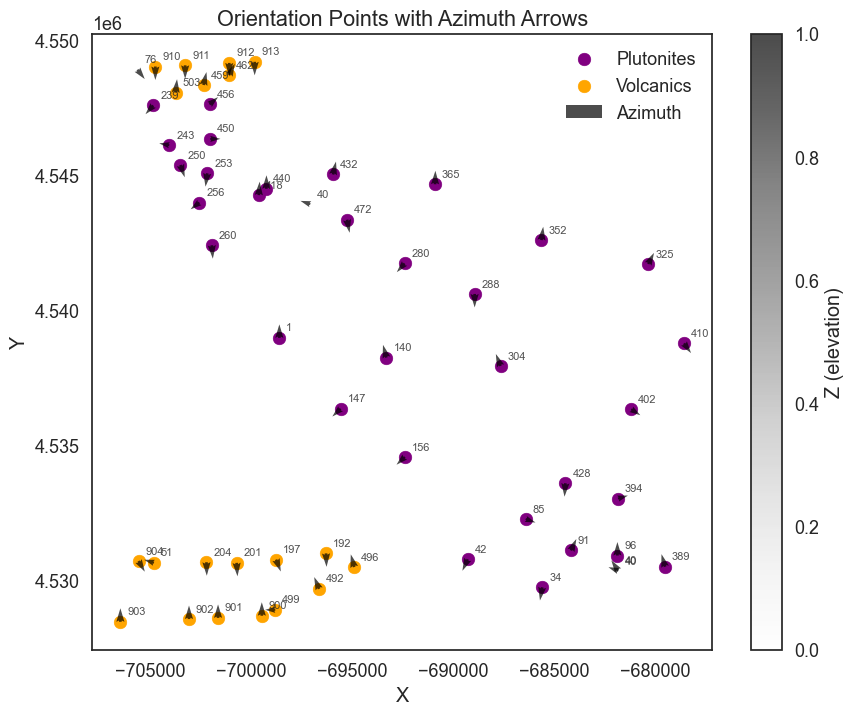

In [81]:
plt.figure(figsize=(10, 8))

Tournaisian_Plutonites = orientations_df[orientations_df['formation']=='Tournaisian Plutonites']
Upper_Carboniferous_Volcanics = orientations_df[orientations_df['formation']=='Upper Carboniferous Volcanics']

plt.scatter(Tournaisian_Plutonites['X'], Tournaisian_Plutonites['Y'], c='purple', label='Plutonites')
plt.scatter(Upper_Carboniferous_Volcanics['X'],Upper_Carboniferous_Volcanics['Y'],c='orange',label='Volcanics')
# Add arrows for azimuth
length = 500  # arrow length in map units
azimuth_rad = np.deg2rad(orientations_df['azimuth'])
dx = length * np.sin(azimuth_rad)
dy = length * np.cos(azimuth_rad)

plt.quiver(
    orientations_df['X'], orientations_df['Y'],
    dx, dy,
    angles='xy', scale_units='xy', scale=1, color='black', width=0.005, alpha=0.7,
    label='Azimuth'
)
# Add text annotations for formation_id
for i, row in orientations_df.iterrows():
    plt.annotate(str(row['formation_id']), 
                (row['X'], row['Y']), 
                xytext=(5, 5), textcoords='offset points', 
                fontsize=8, alpha=0.8)

plt.colorbar(label='Z (elevation)')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Orientation Points with Azimuth Arrows')
plt.legend()

# Sampling code

In [3]:
def smart_sample(sub_df, min_spacing):
    coords = sub_df[['X', 'Y']].values
    tree = cKDTree(coords)
    sampled_indices = []
    mask = np.ones(len(coords), dtype=bool)

    for i in range(len(coords)):
        if mask[i]:
            sampled_indices.append(i)
            neighbors = tree.query_ball_point(coords[i], r=min_spacing)
            mask[neighbors] = False
            mask[i] = True

    return sub_df.iloc[sampled_indices]

In [4]:
def sampling(df,BASE_SPACING=2500,ALPHA=0.50,plotting=False):
    formation_counts = df['formation'].value_counts()
    median_count = formation_counts.median()

    sampled_points = []

    for formation in df['formation'].unique():
        sub_df = df[df['formation'] == formation]
        count = len(sub_df)

        # Penalize formations with more data
        factor = (count / median_count) ** ALPHA
        effective_spacing = BASE_SPACING * factor

        print(f"Formation: {formation}, Points: {count}, Spacing: {effective_spacing:.2f}")

        sampled_df = smart_sample(sub_df, effective_spacing)
        sampled_points.append(sampled_df)

        if plotting == True:
            # Plot
            fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)
            x_min, x_max = df['X'].min(), df['X'].max()
            y_min, y_max = df['Y'].min(), df['Y'].max()

            sc1 = axes[0].scatter(sub_df['X'], sub_df['Y'], c=sub_df['Z'], cmap='viridis', s=10)
            axes[0].set_title(f"Original: {formation}")
            axes[0].set_xlim(x_min, x_max)
            axes[0].set_ylim(y_min, y_max)
            axes[0].set_aspect('equal')
            plt.colorbar(sc1, ax=axes[0], label='Z')

            sc2 = axes[1].scatter(sampled_df['X'], sampled_df['Y'], c=sampled_df['Z'], cmap='viridis', s=10)
            axes[1].set_title(f"Sampled: {formation}")
            axes[1].set_xlim(x_min, x_max)
            axes[1].set_ylim(y_min, y_max)
            axes[1].set_aspect('equal')
            plt.colorbar(sc2, ax=axes[1], label='Z')

            for ax in axes:
                ax.set_xlabel('X')
                ax.set_ylabel('Y')

            plt.tight_layout()
            plt.show()

    # Combine all sampled
    sampled_df_all = pd.concat(sampled_points, ignore_index=True)

    print('-------------------')
    for formation in sampled_df_all['formation'].unique():
        sub_df = sampled_df_all[sampled_df_all['formation'] == formation]
        count = len(sub_df)
        print(f"Formation: {formation}, Points left: {count}")

    return sampled_df_all

In [120]:
sampled_points_df       = sampling(points_df,plotting=False,BASE_SPACING=500, ALPHA=1.0)

Formation: Upper Devonian Siliciclastics, Points: 18, Spacing: 500.00
Formation: Visean Shales, Points: 16, Spacing: 444.44
Formation: Tournaisian Plutonites, Points: 296, Spacing: 8222.22
Formation: Upper Carboniferous Volcanics, Points: 45, Spacing: 1250.00
Formation: Mid Carboniferous Shales, Points: 13, Spacing: 361.11
-------------------
Formation: Upper Devonian Siliciclastics, Points left: 11
Formation: Visean Shales, Points left: 14
Formation: Tournaisian Plutonites, Points left: 7
Formation: Upper Carboniferous Volcanics, Points left: 17
Formation: Mid Carboniferous Shales, Points left: 11


In [ ]:
sampled_orientations_df = sampling(orientations_df, BASE_SPACING=5500, ALPHA=1.90)

Formation: Upper Devonian Siliciclastics, Points: 18, Spacing: 2500.00
Formation: Visean Shales, Points: 16, Spacing: 2357.02
Formation: Tournaisian Plutonites, Points: 296, Spacing: 10137.94
Formation: Upper Carboniferous Volcanics, Points: 45, Spacing: 3952.85
Formation: Mid Carboniferous Shales, Points: 13, Spacing: 2124.59
Formation: Upper Carboniferous Volcanics, Points: 1, Spacing: 5500.00
Formation: Upper Devonian Siliciclastics, Points: 3, Spacing: 44349.94
Formation: Tournaisian Plutonites, Points: 1, Spacing: 5500.00
Formation: Mid Carboniferous Shales, Points: 1, Spacing: 5500.00


|                  |sampled  |oversampled  |
|------------------|---------|-------------|
|normal shape      |gdf3     |             |
|simplified shape  |         |             |


In [99]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np

# Import plutonite data
# gdf1 = gpd.read_file(r"C:\Users\mrcon\Documents\plutonite_points4.gpkg")
gdf4 = gpd.read_file(r"C:\Users\mrcon\Documents\plutonite_points5.gpkg")
gdf3 = gpd.read_file(r"C:\Users\mrcon\Documents\Plutonite_circum_points_incl_dip.gpkg")

# Create a DataFrame with X and Y coordinates
orientations_df = pd.DataFrame({
    'X': gdf3.geometry.x,
    'Y': gdf3.geometry.y,
    'Z': gdf3['elevation1'],
    # 'azimuth': gdf3['az_to_centroid'], # was ['dip'] before
    'azimuth': gdf3['angle'] + 90,
    'dip': 70,
    'polarity': 1,
    'formation': gdf3['GEOLOGY'],
    'formation_id': gdf3['fid']
})

# Skip first 4 rows
orientations_df = orientations_df.iloc[5:].reset_index(drop=True)[::10]

sampled_orientations_path = "sampled_orientationinputpoints10_perfect.csv"
orientations_df.to_csv(sampled_orientations_path, index=False)

In [100]:
points_df = pd.DataFrame({
    'X': gdf3.geometry.x,
    'Y': gdf3.geometry.y,
    'Z': gdf3['elevation1'],
    'formation': gdf3['GEOLOGY'],
    'formation_id': gdf3['fid']
})

points_df_extra = pd.DataFrame({
    'X': gdf4.geometry.x,
    'Y': gdf4.geometry.y,
    'Z': gdf4['elevation1'],
    'formation': 'Tournaisian Plutonites',
    'formation_id': 34
})

# Skip first 4 rows
points_df = points_df.iloc[5:].reset_index(drop=True)
# points_df = pd.concat([points_df, points_df_extra], ignore_index=True)

sampled_points_path = "sampled_formationinputpoints10_perfect.csv"
points_df.to_csv(sampled_points_path, index=False)

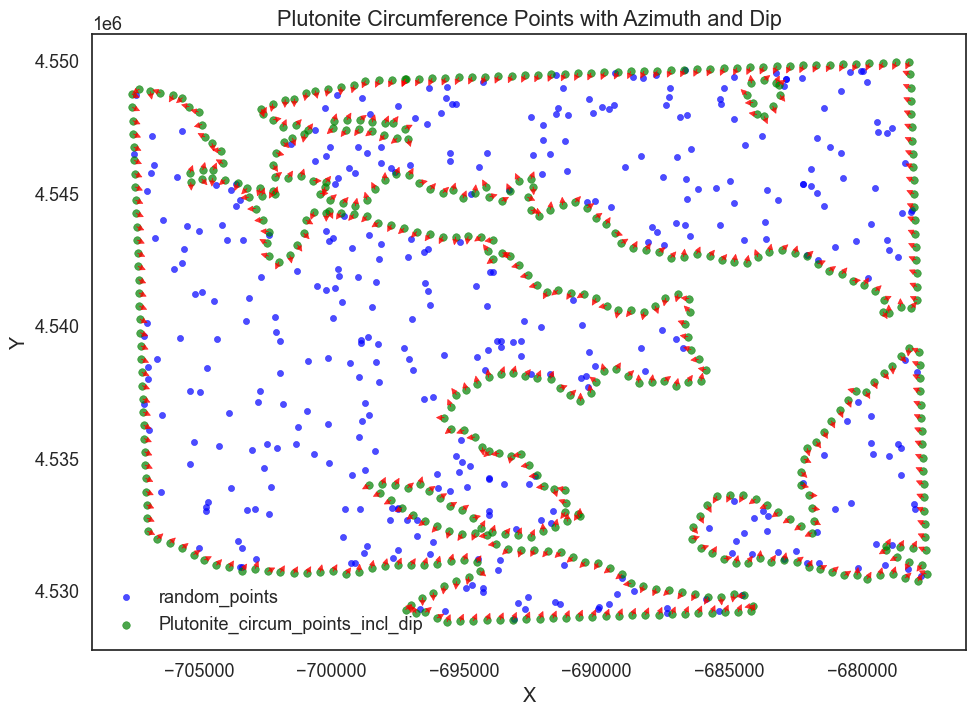

In [101]:
# Plot the points from gdf3
fig, ax = plt.subplots(figsize=(12, 8))

# Plot the points
gdf4.plot(ax=ax, color='blue', markersize=20, alpha=0.7, label='random_points')
gdf3.plot(ax=ax, color='green', markersize=30, alpha=0.7, label='Plutonite_circum_points_incl_dip')


# Add arrows for azimuth where data is available
for idx, row in gdf3.iterrows():
    if pd.notna(row['az_to_centroid']) and pd.notna(row['dip']):
        # Arrow parameters
        arrow_length = 100  # arrow length in map units
        azimuth_rad = np.deg2rad(row['angle'])+90  # Convert azimuth to radians
        dx = arrow_length * np.sin(azimuth_rad)
        dy = arrow_length * np.cos(azimuth_rad)
        
        # Draw arrow
        ax.arrow(row.geometry.x, row.geometry.y, dx, dy, 
                head_width=200, head_length=200, fc='red', ec='red', alpha=0.8)
        

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_title('Plutonite Circumference Points with Azimuth and Dip')
ax.legend()
plt.show()

Could not find element 'In' in any group.
Active grids: GridTypes.NONE|TOPOGRAPHY|DENSE
Setting Backend To: AvailableBackends.numpy
Chunking done: 372 chunks


c:\Users\mrcon\miniconda3\envs\myenv\lib\site-packages\gempy_engine\modules\activator\_soft_segment.py:95: RuntimeWarning: overflow encountered in exp
  return 1.0 / (1.0 + bt.t.exp(x))


Chunking done: 7 chunks
Chunking done: 33 chunks
Chunking done: 12 chunks
Creating cross section...


c:\Users\mrcon\miniconda3\envs\myenv\lib\site-packages\gempy_viewer\API\_plot_2d_API.py:176: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  p.fig.show()


Cross section created!


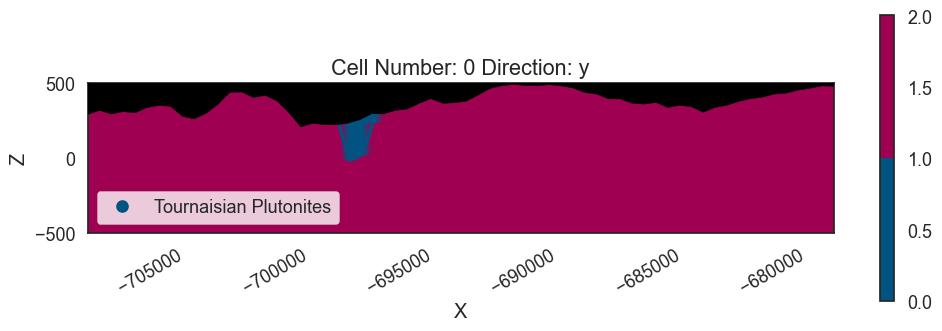

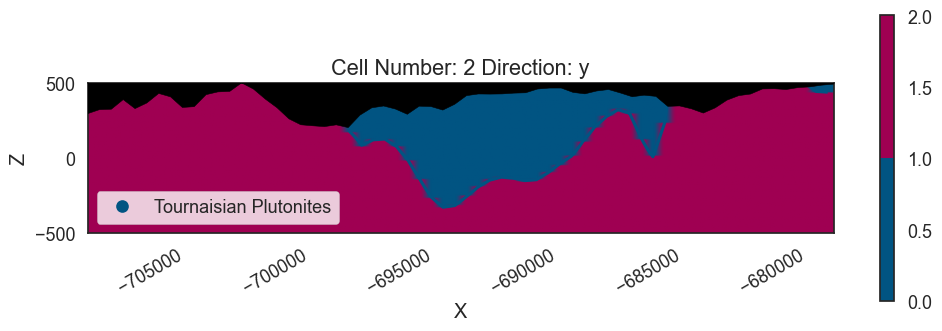

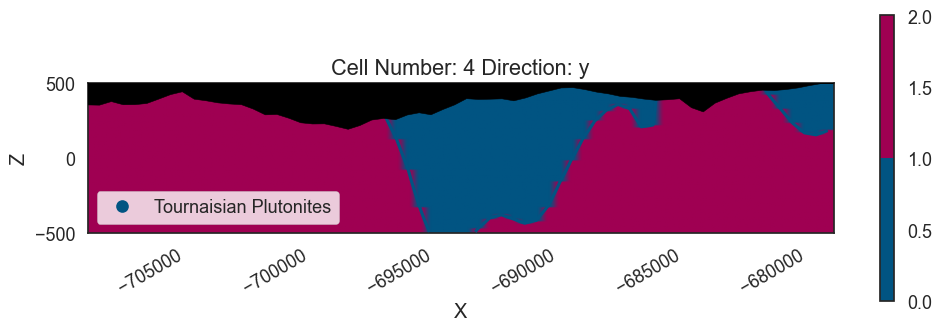

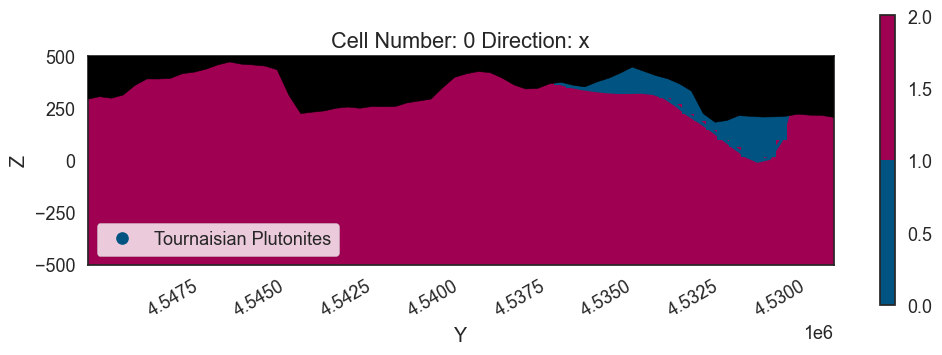

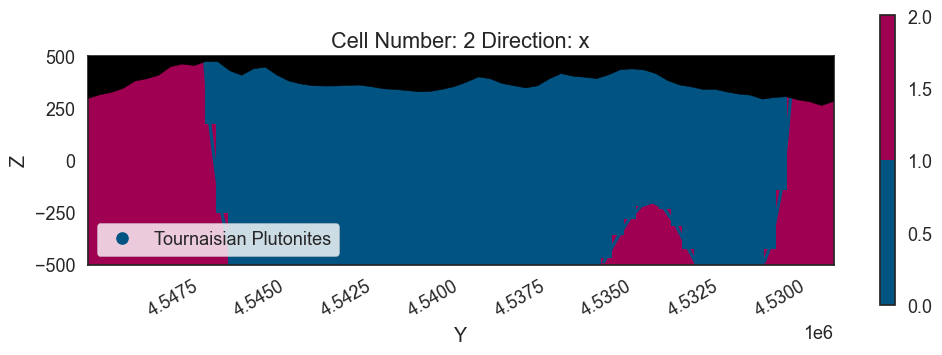

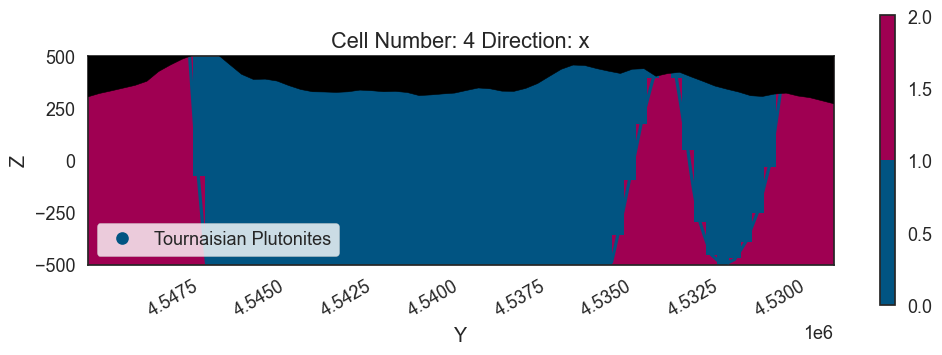

In [102]:
import gempy as gp
import numpy as np
import threading
import gempy as gp
import gempy_engine
import os
import pandas as pd
import HelperMethods
import gempy_viewer as gpv
from gempy_engine.core.data.stack_relation_type import StackRelationType

BASE_DIR = os.getcwd()
data_dir = os.path.join(BASE_DIR, '..', 'Data', 'Tharsis AOI 1')

# 1. Initialize model
top_right = (-678192, 4549947)
bottom_right = (-677518, 4529455)
bottom_left = (-706792, 4528453)
top_left = (-707522, 4548927)

# Calculate bounding box of the area of interest
path_to_data = r"C:\Users\mrcon\OneDrive\Data B\School\GP2\Internship\Mineye\GIS\Tharsis\Output\formationinputpoints.csv"
points_df = pd.read_csv(path_to_data, encoding='latin1', engine='python')
min_x = min(top_left[0], bottom_left[0])
max_x = max(top_right[0], bottom_right[0])
min_y = min(bottom_left[1], bottom_right[1])
max_y = max(top_left[1], top_right[1])
max_z = points_df['Z'].max()
nx = ny = nz = 64  # Define grid resolution
model_depth = -500

geo_model = gp.create_geomodel(
    project_name='AOI',
    extent=[min_x, max_x, max_y, min_y, model_depth, max_z],
    # refinement=6,
    resolution=[nx, ny, nz],
    importer_helper=gp.data.ImporterHelper(
        # path_to_orientations=os.path.join(BASE_DIR, "sampled_orientationinputpoints3.csv"),
        # path_to_surface_points=os.path.join(BASE_DIR, "sampled_formationinputpoints4.csv"),
        #.....
        # path_to_orientations=os.path.join(BASE_DIR, "sampled_orientationinputpoints5.csv"),
        # path_to_surface_points=os.path.join(BASE_DIR, "sampled_formationinputpoints5.csv"),
        #.....
        path_to_orientations=os.path.join(BASE_DIR, "sampled_orientationinputpoints10_perfect.csv"),
        path_to_surface_points=os.path.join(BASE_DIR, "sampled_formationinputpoints10_perfect.csv"),
    )
)

gp.map_stack_to_surfaces(
    gempy_model=geo_model,
    mapping_object={
        "Tournaisian_Plutonites_S": ["In"],
    }
)

path_to_topography_reduced = os.path.join(data_dir, 'topo_reduced_sf0.1.tif')
gp.set_topography_from_file(grid=geo_model.grid, filepath=path_to_topography_reduced)

gempy_model = gp.compute_model(geo_model)

threading.Thread(target=HelperMethods.plot_3d_async, args=(geo_model,)).start()
trigger_create_cross_section = True
if trigger_create_cross_section:
    print("Creating cross section...")
    HelperMethods.create_cross_section(geo_model, cross_section=5)
    print("Cross section created!")
else:
    print("Cross section creation is disabled")

In [104]:
import numpy as np

# 1. Get the formation IDs for the model
# The interpolated grid of formation IDs is stored here
lith_block = geo_model.solutions.raw_arrays.lith_block
lith_block_reshaped = lith_block.reshape(64,64,64)


# 2. Identify the formation ID of the Plutonite
plutonite_id = 1

# 3. Create a boolean mask for plutonite voxels
plutonite_mask = lith_block_reshaped == plutonite_id

# 4. Get the coordinates of these voxels
voxel_coords = geo_model.grid.regular_grid.values
voxel_coords_reshaped = voxel_coords.reshape(64, 64, 64, 3)


# Select only the coordinates where lith_block == 1
plutonite_coords = voxel_coords_reshaped[plutonite_mask]
# # Flip Y coordinate
# Flip Y to match input data range
y_min, y_max = np.min(plutonite_coords[:, 1]), np.max(plutonite_coords[:, 1])
plutonite_coords_flipped = plutonite_coords.copy()
plutonite_coords_flipped[:, 1] = y_max - (plutonite_coords[:, 1] - y_min)


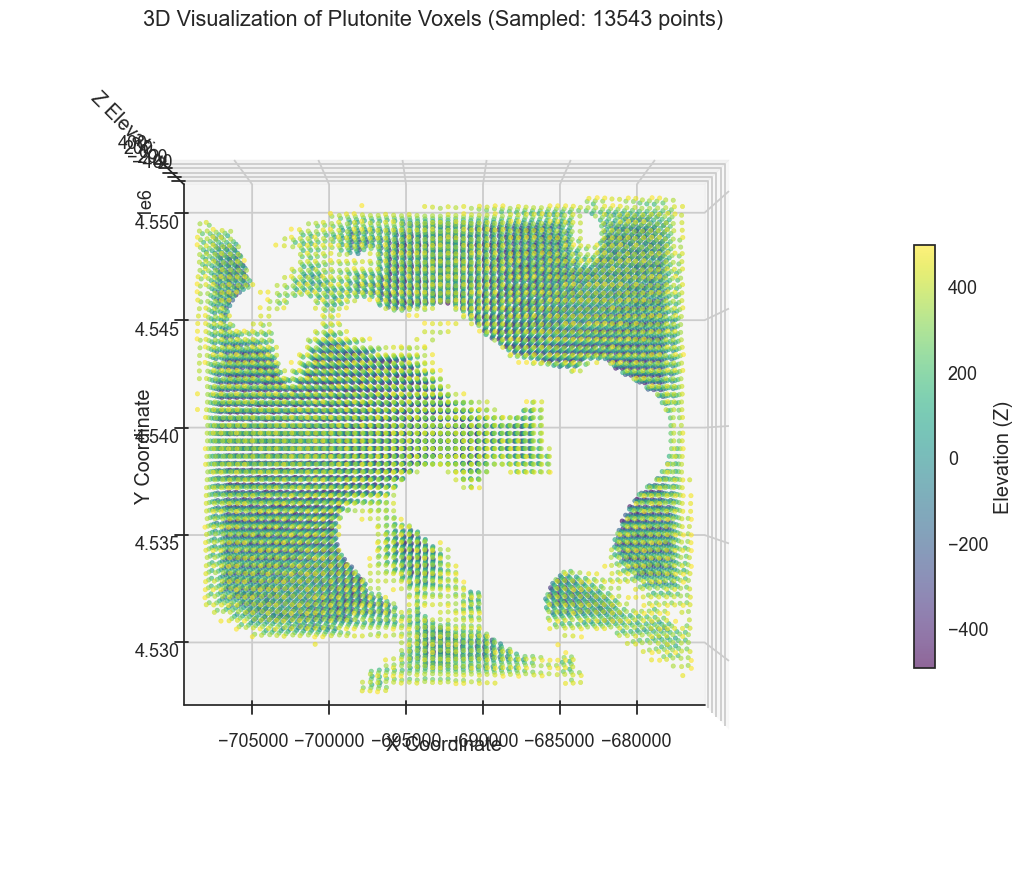

Original plutonite coordinates: 135427 points
Sampled plutonite coordinates: 13543 points


In [105]:
# Sample the plutonite coordinates for better performance
sample_step = 10  # Take every 10th point
plutonite_coords_sampled = plutonite_coords_flipped[::sample_step]

# Create interactive 3D plot
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

# Create the scatter plot with color mapping based on Z values
scatter = ax.scatter(plutonite_coords_sampled[:,0], 
                    plutonite_coords_sampled[:,1], 
                    plutonite_coords_sampled[:,2],
                    c=plutonite_coords_sampled[:,2], 
                    cmap='viridis', 
                    s=10, 
                    alpha=0.6)

# Add colorbar
plt.colorbar(scatter, ax=ax, label='Elevation (Z)', shrink=0.5)

# Set labels and title
ax.set_xlabel('X Coordinate')
ax.set_ylabel('Y Coordinate')
ax.set_zlabel('Z Elevation')
ax.set_title(f'3D Visualization of Plutonite Voxels (Sampled: {len(plutonite_coords_sampled)} points)')

# Improve the view
ax.view_init(elev=90, azim=270)

plt.tight_layout()
plt.show()

print(f"Original plutonite coordinates: {len(plutonite_coords)} points")
print(f"Sampled plutonite coordinates: {len(plutonite_coords_sampled)} points")

# Experiment: Exporting part of a geomodel into another geomodel

In [220]:
import gempy as gp
import pandas as pd
import numpy as np

# Parameters
center_x, center_y = 0, 0
radius = 50
num_points = 36
z_value = 100  # elevation
dip_angle = 45  # horizontal

# Generate angles for points around the circle
angles = np.linspace(0, 2 * np.pi, num_points, endpoint=False)

# X, Y coordinates of points
X = center_x + radius * np.cos(angles)
Y = center_y + radius * np.sin(angles)
Z = np.full_like(X, z_value)

# Inward-pointing azimuths (degrees from north)
azimuths_inwards = (np.degrees(np.arctan2(center_x - X, center_y - Y)) + 360) % 360

# Create DataFrame for surface points
surface_points = pd.DataFrame({
    'X': X,
    'Y': Y,
    'Z': Z,
    'formation': 'Igneous Rock',
    'formation_id': np.ones(num_points, dtype=int)
})

# Create DataFrame for orientations
orientations = pd.DataFrame({
    'X': X,
    'Y': Y,
    'Z': Z,
    'trend': azimuths_inwards,  # azimuths pointing inward
    'plunge': np.full_like(X, dip_angle),
    'polarity': 1,
    'formation': 'Igneous Rock',
    'formation_id': np.ones(num_points, dtype=int)
})


# ------------------------
# 2. Initialize GemPy model
# ------------------------

# Define the extent of the model
extent = [center_x - 60, center_x + 60,
          center_y - 60, center_y + 60,
          z_value - 50, z_value]

# Initialize the GemPy model
geo_model = gp.create_geomodel(
    project_name='Igneous_Rock_Circle',
    extent=extent,
    resolution=[50, 50, 50],
    structural_frame=gp.data.StructuralFrame.initialize_default_structure()
    )

geo_model.structural_frame.structural_elements[0].color = '#33ABFF'  # Set 'surface 1' color to blue.
geo_model.structural_frame.structural_elements[1].color = '#570987'  # Set basement color to purple.

geo_model.structural_frame.structural_elements[0].name = 'Igneous Rock'  # Renaming 'surface 1' to 'Igneous Rock'.

gp.add_surface_points(
    geo_model=geo_model,
    x=surface_points['X'].values,
    y=surface_points['Y'].values,
    z=surface_points['Z'].values,
    elements_names=['Igneous Rock'] * len(surface_points),
)

trend_rad = np.radians(azimuths_inwards)
plunge_rad = np.radians(np.full_like(X, dip_angle))
pole_vectors = pd.DataFrame({
    'px': np.sin(plunge_rad) * np.sin(trend_rad),
    'py': np.sin(plunge_rad) * np.cos(trend_rad),
    'pz': np.cos(plunge_rad)
})

gp.add_orientations(
    geo_model=geo_model,
    x=orientations['X'].values,
    y=orientations['Y'].values,
    z=orientations['Z'].values,
    elements_names=['Igneous Rock'] * len(orientations),
    pole_vector=pole_vectors
)

# # ------------------------
# # 3. Interpolate the model
# # ------------------------
gp.compute_model(geo_model, engine_config=gp.data.GemPyEngineConfig())

# # ------------------------
# # 4. Plot the model
# # ------------------------
gpv.plot_3d(geo_model, show_topography=True)


Setting Backend To: AvailableBackends.numpy


c:\Users\mrcon\miniconda3\envs\myenv\lib\site-packages\gempy_engine\core\data\transforms.py:215: RuntimeWarning: Interpolation is being done with the default transform. If you do not know what you are doing you should probably call GeoModel.update_transform() first.
  warnings.warn(


Chunking done: 37 chunks


c:\Users\mrcon\miniconda3\envs\myenv\lib\site-packages\gempy_engine\modules\activator\_soft_segment.py:95: RuntimeWarning: overflow encountered in exp
  return 1.0 / (1.0 + bt.t.exp(x))


In [221]:
import numpy as np

# 1. Get the formation IDs for the model
# The interpolated grid of formation IDs is stored here
lith_block = geo_model.solutions.raw_arrays.lith_block
lith_block_reshaped = lith_block.reshape(50,50,50)


# 2. Identify the formation ID of the Igneous Rock
igneous_rock_id = 1

# 3. Create a boolean mask for igneous rock voxels
igneous_rock_mask = lith_block_reshaped == igneous_rock_id

# 4. Get the coordinates of these voxels
voxel_coords = geo_model.grid.regular_grid.values
voxel_coords_reshaped = voxel_coords.reshape(50, 50, 50, 3)

# Select only the coordinates where lith_block == 1
igneous_rock_coords = voxel_coords_reshaped[igneous_rock_mask]
# # Flip Y coordinate
# Flip Y to match input data range
y_min, y_max = np.min(igneous_rock_coords[:, 1]), np.max(igneous_rock_coords[:, 1])
igneous_rock_coords_flipped = igneous_rock_coords.copy()
igneous_rock_coords_flipped[:, 1] = y_max - (igneous_rock_coords[:, 1] - y_min)


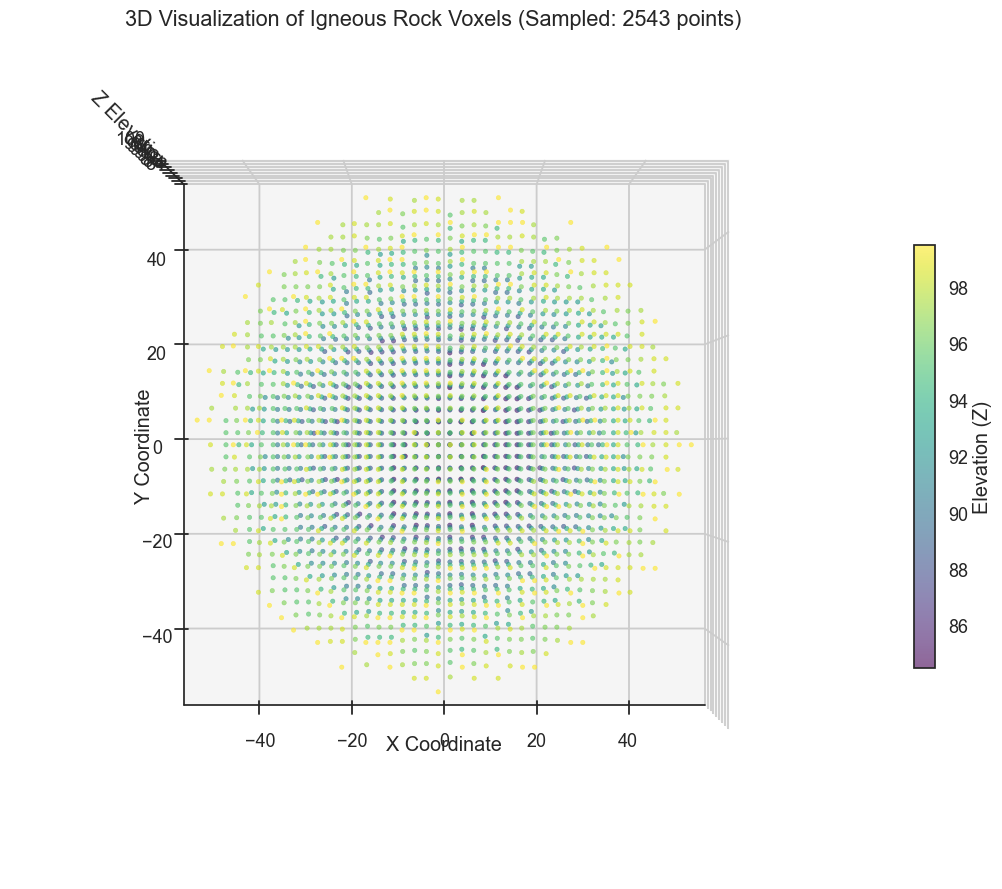

Original igneous rock coordinates: 12712 points
Sampled igneous rock coordinates: 2543 points


In [222]:
# Sample the igneous rock coordinates for better performance
sample_step = 5  # Take every 10th point
igneous_rock_coords_sampled = igneous_rock_coords_flipped[::sample_step]

# Create interactive 3D plot
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

# Create the scatter plot with color mapping based on Z values
scatter = ax.scatter(igneous_rock_coords_sampled[:,0], 
                    igneous_rock_coords_sampled[:,1], 
                    igneous_rock_coords_sampled[:,2],
                    c=igneous_rock_coords_sampled[:,2], 
                    cmap='viridis', 
                    s=10, 
                    alpha=0.6)

# Add colorbar
plt.colorbar(scatter, ax=ax, label='Elevation (Z)', shrink=0.5)

# Set labels and title
ax.set_xlabel('X Coordinate')
ax.set_ylabel('Y Coordinate')
ax.set_zlabel('Z Elevation')
ax.set_title(f'3D Visualization of Igneous Rock Voxels (Sampled: {len(igneous_rock_coords_sampled)} points)')

# Improve the view
ax.view_init(elev=90, azim=270)

plt.tight_layout()
plt.show()

print(f"Original igneous rock coordinates: {len(igneous_rock_coords)} points")
print(f"Sampled igneous rock coordinates: {len(igneous_rock_coords_sampled)} points")

In [223]:
# Parameters
center_x, center_y = 0, 0
radius = 50
num_points = 36
z_value = 100  # elevation
dip_angle = 0

# Generate angles for points around the circle
angles = np.linspace(0, 2 * np.pi, num_points, endpoint=False)

# X, Y coordinates of points
X = center_x + radius * np.cos(angles)
Y = center_y + radius * np.sin(angles)
Z = np.full_like(X, z_value)

# Inward-pointing azimuths (degrees from north)
azimuths_inwards = (np.degrees(np.arctan2(center_x - X, center_y - Y)) + 360) % 360

# Create DataFrame for surface points
surface_points_stratigraphy1 = pd.DataFrame({
    'X': X,
    'Y': Y,
    'Z': Z-25,
    'formation': 'Claystone',
    'formation_id': np.ones(num_points, dtype=int)
})

# Create DataFrame for surface points
surface_points_stratigraphy2 = pd.DataFrame({
    'X': X,
    'Y': Y,
    'Z': Z-50,
    'formation': 'Sandstone',
    'formation_id': 2*np.ones(num_points, dtype=int)
})

# Create DataFrame for surface points
surface_points_stratigraphy3 = pd.DataFrame({
    'X': X,
    'Y': Y,
    'Z': Z-75,
    'formation': 'Mudstone',
    'formation_id': 3*np.ones(num_points, dtype=int)
})

# Create DataFrame for orientations
orientations_stratigraphy1 = pd.DataFrame({
    'X': X,
    'Y': Y,
    'Z': Z-25,
    'azimuth': azimuths_inwards,  # azimuths pointing inward
    'dip': np.full_like(X, dip_angle),
    'polarity': 1,
    'formation': 'Claystone',
    'formation_id': np.ones(num_points, dtype=int)
})

# Create DataFrame for orientations
orientations_stratigraphy2 = pd.DataFrame({
    'X': X,
    'Y': Y,
    'Z': Z-50,
    'azimuth': azimuths_inwards,  # azimuths pointing inward
    'dip': np.full_like(X, dip_angle),
    'polarity': 1,
    'formation': 'Sandstone',
    'formation_id': 2*np.ones(num_points, dtype=int)
})

# Create DataFrame for orientations
orientations_stratigraphy3 = pd.DataFrame({
    'X': X,
    'Y': Y,
    'Z': Z-75,
    'azimuth': azimuths_inwards,  # azimuths pointing inward
    'dip': np.full_like(X, dip_angle),
    'polarity': 1,
    'formation': 'Mudstone',
    'formation_id': 3*np.ones(num_points, dtype=int)
})

# Combine all stratigraphic points and orientations
stratigraphic_points = pd.concat([surface_points_stratigraphy1, surface_points_stratigraphy2, surface_points_stratigraphy3], ignore_index=True)
stratigraphic_orientations = pd.concat([orientations_stratigraphy1, orientations_stratigraphy2, orientations_stratigraphy3], ignore_index=True)
stratigraphic_points.to_csv("stratigraphic_points.csv", index=False)
stratigraphic_orientations.to_csv("stratigraphic_orientations.csv", index=False)

In [224]:

# ------------------------
# 2. Initialize GemPy model
# ------------------------

# Define the extent of the model
extent = [center_x - 60, center_x + 60,
          center_y - 60, center_y + 60,
          z_value - 100, z_value]


geo_model2: gp.data.GeoModel = gp.create_geomodel(
    project_name='Stratigraphic_model',
    extent=extent,
    resolution=[50, 50, 50],
    importer_helper=gp.data.ImporterHelper(
        path_to_orientations="stratigraphic_orientations.csv",
        path_to_surface_points="stratigraphic_points.csv"
    )
)

# 3. Define units (surfaces) and assign to series
# Update the structural frame to include all formations from the data
gp.map_stack_to_surfaces(
    gempy_model=geo_model,
    mapping_object={
        "Strat_Series": ["Claystone", "Sandstone", "Mudstone"],
    }
)

# # # ------------------------
# # # 3. Interpolate the model
# # # ------------------------
gp.compute_model(geo_model2, engine_config=gp.data.GemPyEngineConfig())

# # # ------------------------
# # # 4. Plot the model
# # # ------------------------
gpv.plot_3d(geo_model2, show_topography=True)

geo_model2.structural_frame

Could not find element 'Claystone' in any group.
Could not find element 'Sandstone' in any group.
Could not find element 'Mudstone' in any group.
Setting Backend To: AvailableBackends.numpy
Chunking done: 109 chunks


c:\Users\mrcon\miniconda3\envs\myenv\lib\site-packages\gempy_engine\modules\activator\_soft_segment.py:95: RuntimeWarning: overflow encountered in exp
  return 1.0 / (1.0 + bt.t.exp(x))


Chunking done: 18 chunks


StructuralFrame(
	structural_groups=[
StructuralGroup(
	name=default_formation,
	structural_relation=StackRelationType.ERODE,
	elements=[
Element(
	name=Claystone,
	color=#015482,
	is_active=True
),
Element(
	name=Sandstone,
	color=#ffbe00,
	is_active=True
),
Element(
	name=Mudstone,
	color=#9f0052,
	is_active=True
)
]
)
],
	fault_relations=
[[False]],

In [ ]:
# def convert_orientation_to_pole_vector(azimuth, dip, polarity):
#     # Convert sequences to numpy arrays for vectorized operations
#     azimuth = np.array(azimuth)
#     dip = np.array(dip)
#     polarity = np.array(polarity)

#     # Calculate gradient components
#     G_x = np.sin(np.deg2rad(dip)) * np.sin(np.deg2rad(azimuth)) * polarity
#     G_y = np.sin(np.deg2rad(dip)) * np.cos(np.deg2rad(azimuth)) * polarity
#     G_z = np.cos(np.deg2rad(dip)) * polarity

#     # Combine gradient components into an array of vectors
#     gradients = np.vstack([G_x, G_y, G_z]).T

#     return gradients

In [269]:
import numpy as np

# 1. Get the formation IDs for the model
# The interpolated grid of formation IDs is stored here
lith_block = geo_model2.solutions.raw_arrays.lith_block
lith_block_reshaped = lith_block.reshape(50,50,50)

# 4. Get the coordinates of these voxels
voxel_coords = geo_model2.grid.regular_grid.values
voxel_coords_reshaped = voxel_coords.reshape(50, 50, 50, 3)

# # Flip Y coordinate
# Flip Y to match input data range
# y_min, y_max = np.min(plutonite_coords[:, 1]), np.max(plutonite_coords[:, 1])
# plutonite_coords_flipped = plutonite_coords.copy()
# plutonite_coords_flipped[:, 1] = y_max - (plutonite_coords[:, 1] - y_min)

# Find which formations are present in each voxel of the stratigraphic model
# claystone_id = 1
# sandstone_id = 2
# mudstone_id = 3

# Insert the igneous rock locations into the stratigraphic model
lith_block_reshaped[igneous_rock_mask] = 5
lith_block_modified = lith_block_reshaped.flatten()

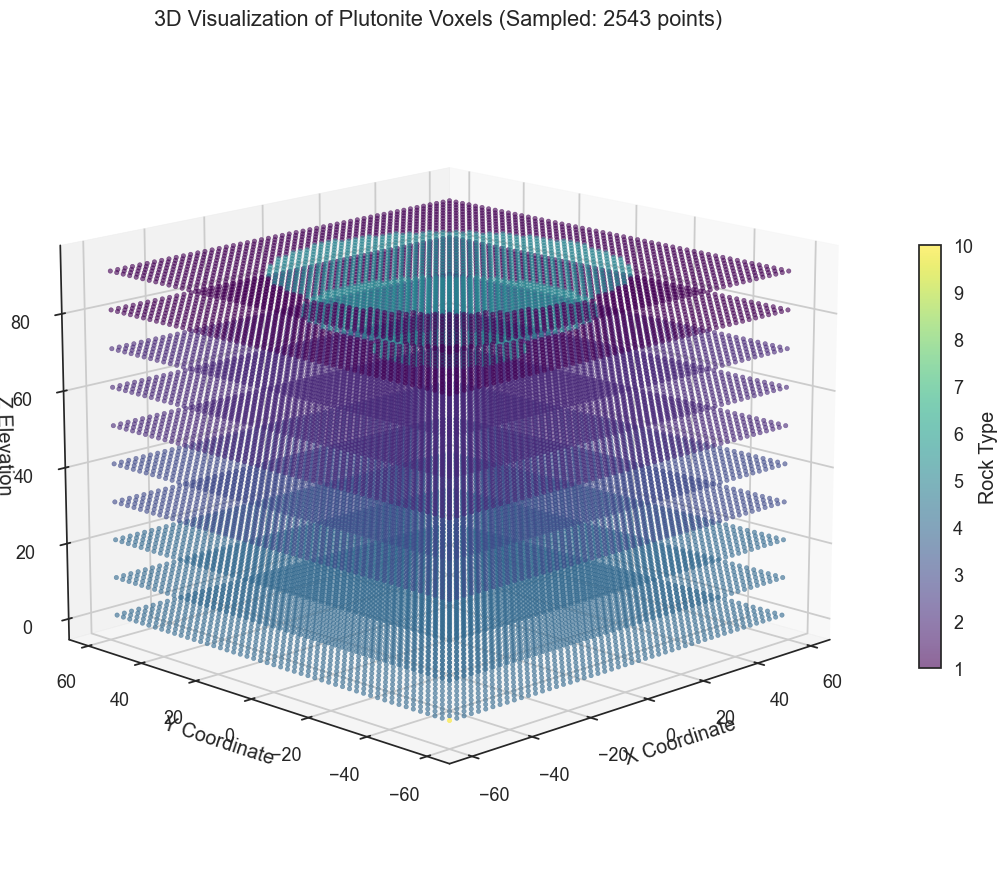

Original plutonite coordinates: 12712 points
Sampled plutonite coordinates: 2543 points


In [270]:
# Sample the plutonite coordinates for better performance
sample_step = 5  # Take every 10th point

# Create interactive 3D plot
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

# Create the scatter plot with color mapping based on Z values
scatter = ax.scatter(voxel_coords[:,0][::sample_step], 
                    voxel_coords[:,1][::sample_step], 
                    voxel_coords[:,2][::sample_step],
                    c=lith_block_modified[::sample_step], 
                    cmap='viridis', 
                    s=10, 
                    alpha=0.6)

# Add colorbar
plt.colorbar(scatter, ax=ax, label='Rock Type', shrink=0.5)

# Set labels and title
ax.set_xlabel('X Coordinate')
ax.set_ylabel('Y Coordinate')
ax.set_zlabel('Z Elevation')
ax.set_title(f'3D Visualization of Plutonite Voxels (Sampled: {len(plutonite_coords_sampled)} points)')

# Improve the view
ax.view_init(elev=15, azim=225)
plt.tight_layout()
plt.show()

print(f"Original plutonite coordinates: {len(plutonite_coords)} points")
print(f"Sampled plutonite coordinates: {len(plutonite_coords_sampled)} points")

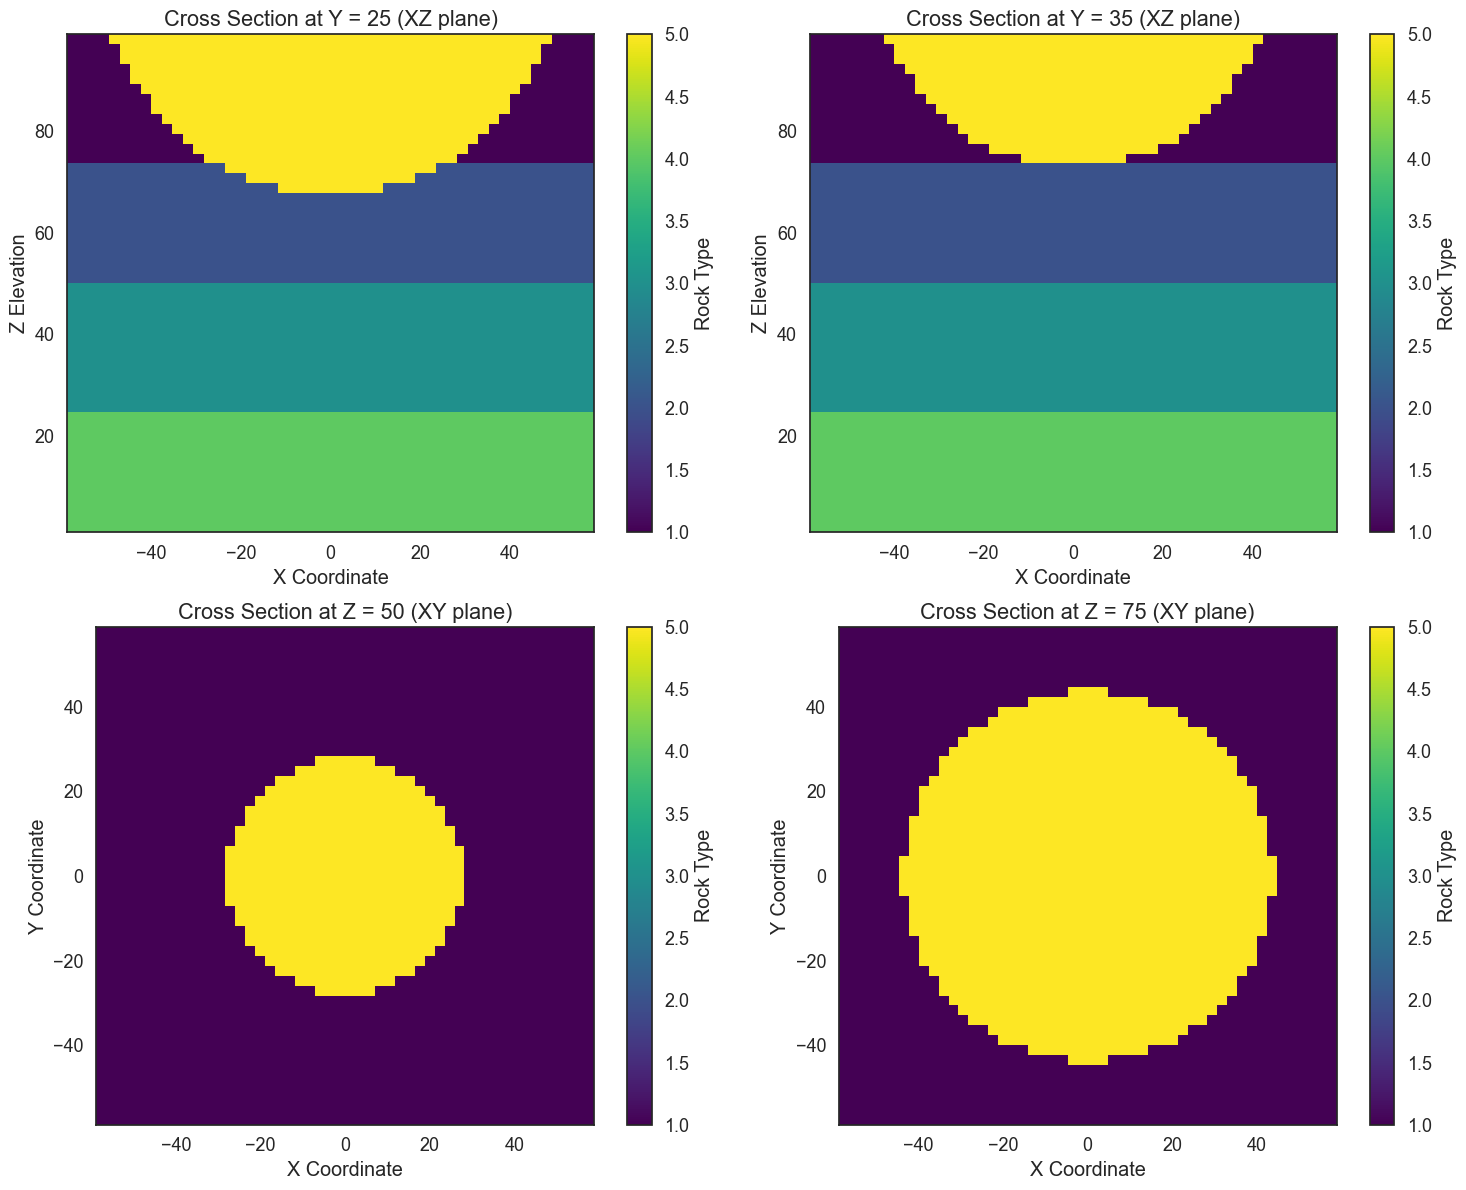

Rock Type Legend:
1: Claystone
2: Sandstone
3: Mudstone
4: Basement
5: Igneous Rock (Intrusion)


In [271]:
# Create 2D cross sections of the combined model
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Cross section at Y = 0 (XZ plane)
y_index1 = 25  # Middle index for Y dimension
xz_slice1 = lith_block_modified.reshape(50, 50, 50)[:, y_index1, :]
im1 = axes[0, 0].imshow(xz_slice1.T, cmap='viridis', origin='lower', 
                        extent=[-58.8, 58.8, 1, 99], aspect='auto')
axes[0, 0].set_title('Cross Section at Y = 25 (XZ plane)')
axes[0, 0].set_xlabel('X Coordinate')
axes[0, 0].set_ylabel('Z Elevation')
plt.colorbar(im1, ax=axes[0, 0], label='Rock Type')

# Cross section at Y = 35 (XZ plane)
y_index2 = 35  # Off-Middle index for Y dimension
xz_slice2 = lith_block_modified.reshape(50, 50, 50)[:, y_index2, :]
im2 = axes[0, 1].imshow(xz_slice2.T, cmap='viridis', origin='lower',
                        extent=[-58.8, 58.8, 1, 99], aspect='auto')
axes[0, 1].set_title('Cross Section at Y = 35 (XZ plane)')
axes[0, 1].set_xlabel('X Coordinate')
axes[0, 1].set_ylabel('Z Elevation')
plt.colorbar(im2, ax=axes[0, 1], label='Rock Type')

# Cross section at Z = 50 (XY plane)
z_index = 37  # Middle index for Z dimension
xy_slice = lith_block_modified.reshape(50, 50, 50)[:, :, z_index]
im3 = axes[1, 0].imshow(xy_slice.T, cmap='viridis', origin='lower',
                        extent=[-58.8, 58.8, -58.8, 58.8], aspect='equal')
axes[1, 0].set_title('Cross Section at Z = 50 (XY plane)')
axes[1, 0].set_xlabel('X Coordinate')
axes[1, 0].set_ylabel('Y Coordinate')
plt.colorbar(im3, ax=axes[1, 0], label='Rock Type')

# Cross section at Z = 75 (XY plane) - upper level
z_index = 45  # Upper index for Z dimension
xy_slice_upper = lith_block_modified.reshape(50, 50, 50)[:, :, z_index]
im4 = axes[1, 1].imshow(xy_slice_upper.T, cmap='viridis', origin='lower',
                        extent=[-58.8, 58.8, -58.8, 58.8], aspect='equal')
axes[1, 1].set_title('Cross Section at Z = 75 (XY plane)')
axes[1, 1].set_xlabel('X Coordinate')
axes[1, 1].set_ylabel('Y Coordinate')
plt.colorbar(im4, ax=axes[1, 1], label='Rock Type')

plt.tight_layout()
plt.show()

# Add legend for rock types
print("Rock Type Legend:")
print("1: Claystone")
print("2: Sandstone") 
print("3: Mudstone")
print("4: Basement")
print("5: Igneous Rock (Intrusion)")

# Stratigraphic Model

In [167]:
import pandas as pd
import geopandas as gpd
path_to_data = r"C:\Users\mrcon\OneDrive\Data B\School\GP2\Internship\Mineye\GIS\Tharsis\Output\formationinputpoints.csv"
path_to_orientations = r"C:\Users\mrcon\OneDrive\Data B\School\GP2\Internship\Mineye\GIS\Tharsis\Output\orientations.csv"
points_df = pd.read_csv(path_to_data)
orientations_df = pd.read_csv(path_to_orientations)

# points_df_stratigraphic = points_df[points_df['formation'].isin(['Upper Devonian Siliciclastics', 
#                                                                  'Visean Shales',
#                                                                  'Upper Carboniferous Volcanics',
#                                                                  'Mid Carboniferous Shales'])].reset_index(drop=True)

# orientations_df_stratigraphic = orientations_df[orientations_df['formation'].isin(['Upper Devonian Siliciclastics', 
#                                                                  'Visean Shales',
#                                                                  'Upper Carboniferous Volcanics',
#                                                                  'Mid Carboniferous Shales'])].reset_index(drop=True)


points_incl_topo1 = gpd.read_file(r"C:\Users\mrcon\Documents\points_incl_topo.gpkg")
points_incl_topo2 = gpd.read_file(r"C:\Users\mrcon\Documents\points22_incl_topo.gpkg")
points_incl_topo3 = gpd.read_file(r"C:\Users\mrcon\Documents\points3_incl_topo.gpkg")
points_incl_topo4 = gpd.read_file(r"C:\Users\mrcon\Documents\points4_incl_topo.gpkg")

points_orientations_incl_topo1 = gpd.read_file(r"C:\Users\mrcon\Documents\points_orientations_incl_topo.gpkg")
points_orientations_incl_topo2 = gpd.read_file(r"C:\Users\mrcon\Documents\points2_orientations_incl_topo.gpkg")
points_orientations_incl_topo3 = gpd.read_file(r"C:\Users\mrcon\Documents\points3_orientations_incl_topo.gpkg")
points_orientations_incl_topo4 = gpd.read_file(r"C:\Users\mrcon\Documents\points4_orientations_incl_topo.gpkg")

points_incl_topo1_df = pd.DataFrame({
    'X': points_incl_topo1.geometry.x,
    'Y': points_incl_topo1.geometry.y,
    'Z': points_incl_topo1['elevation1'],
    'formation': points_incl_topo1['geology'],
    'formation_id': points_incl_topo1['id']
})

points_incl_topo1_df = points_incl_topo1_df.loc[2:]

points_incl_topo2_df = pd.DataFrame({
    'X': points_incl_topo2.geometry.x,
    'Y': points_incl_topo2.geometry.y,
    'Z': points_incl_topo2['elevation1'],
    'formation': points_incl_topo2['geology'],
    'formation_id': points_incl_topo2['id']
})

points_incl_topo3_df = pd.DataFrame({
    'X': points_incl_topo3.geometry.x,
    'Y': points_incl_topo3.geometry.y,
    'Z': points_incl_topo3['elevation1'],
    'formation': points_incl_topo3['geology'],
    'formation_id': points_incl_topo3['id']
})

points_incl_topo4_df = pd.DataFrame({
    'X': points_incl_topo4.geometry.x,
    'Y': points_incl_topo4.geometry.y,
    'Z': points_incl_topo4['elevation1'],
    'formation': points_incl_topo4['geology'],
    'formation_id': points_incl_topo4['id']
})

points_incl_topo_all_df = pd.concat([points_incl_topo1_df, points_incl_topo2_df, points_incl_topo3_df, points_incl_topo4_df], ignore_index=True)




points_orientations_incl_topo1_df = pd.DataFrame({
    'X': points_orientations_incl_topo1.geometry.x,
    'Y': points_orientations_incl_topo1.geometry.y,
    'Z': points_orientations_incl_topo1['elevation1'],
    'azimuth': points_orientations_incl_topo1['azimuth'],
    'dip': points_orientations_incl_topo1['dip'],
    'polarity': 1,
    'formation': points_orientations_incl_topo1['geology'],
    'formation_id': points_orientations_incl_topo1['id']
})

points_orientations_incl_topo2_df = pd.DataFrame({
    'X': points_orientations_incl_topo2.geometry.x,
    'Y': points_orientations_incl_topo2.geometry.y,
    'Z': points_orientations_incl_topo2['elevation1'],
    'azimuth': points_orientations_incl_topo2['azimuth'],
    'dip': points_orientations_incl_topo2['dip'],
    'polarity': 1,
    'formation': points_orientations_incl_topo2['geology'],
    'formation_id': points_orientations_incl_topo2['id']
})

points_orientations_incl_topo3_df = pd.DataFrame({
    'X': points_orientations_incl_topo3.geometry.x,
    'Y': points_orientations_incl_topo3.geometry.y,
    'Z': points_orientations_incl_topo3['elevation1'],
    'azimuth': points_orientations_incl_topo3['azimuth'],
    'dip': points_orientations_incl_topo3['dip'],
    'polarity': 1,
    'formation': points_orientations_incl_topo3['geology'],
    'formation_id': points_orientations_incl_topo3['id']
})

points_orientations_incl_topo4_df = pd.DataFrame({
    'X': points_orientations_incl_topo4.geometry.x,
    'Y': points_orientations_incl_topo4.geometry.y,
    'Z': points_orientations_incl_topo4['elevation1'],
    'azimuth': points_orientations_incl_topo4['azimuth'],
    'dip': points_orientations_incl_topo4['dip'],
    'polarity': 1,
    'formation': points_orientations_incl_topo4['geology'],
    'formation_id': points_orientations_incl_topo4['id']
})

points_orientations_incl_topo_all_df = pd.concat([points_orientations_incl_topo1_df.loc[:18], points_orientations_incl_topo2_df, points_orientations_incl_topo3_df, points_orientations_incl_topo4_df], ignore_index=True)




# Upper layer Upper Carboniferous Volcanics id = 1
points_incl_topo_all_df.loc[points_incl_topo_all_df['formation'] == 'Upper Carboniferous Volcanics', 'formation_id'] = 1
points_orientations_incl_topo_all_df.loc[points_orientations_incl_topo_all_df['formation'] == 'Upper Carboniferous Volcanics', 'formation_id'] = 1

# Upper layer Mid Carboniferous Shales id = 2
points_incl_topo_all_df.loc[points_incl_topo_all_df['formation'] == 'Mid Carboniferous Shales', 'formation_id'] = 2
points_orientations_incl_topo_all_df.loc[points_orientations_incl_topo_all_df['formation'] == 'Mid Carboniferous Shales', 'formation_id'] = 2

# Upper layer Visean Shales id = 3
points_incl_topo_all_df.loc[points_incl_topo_all_df['formation'] == 'Visean Shales', 'formation_id'] = 3
points_orientations_incl_topo_all_df.loc[points_orientations_incl_topo_all_df['formation'] == 'Visean Shales', 'formation_id'] = 3

# Upper layer Upper Devonian Siliciclastics id = 4
points_incl_topo_all_df.loc[points_incl_topo_all_df['formation'] == 'Upper Devonian Siliciclastics', 'formation_id'] = 4
points_orientations_incl_topo_all_df.loc[points_orientations_incl_topo_all_df['formation'] == 'Upper Devonian Siliciclastics', 'formation_id'] = 4

points_incl_topo_all_df.to_csv("points_incl_topo_all_df.csv", index=False)
points_orientations_incl_topo_all_df.to_csv("points_orientations_incl_topo_all_df.csv", index=False)

# Formation Legend
# 1 = Upper Carboniferous Volcanics
# 2 = Mid Carboniferous Shales
# 3 = Visean Shales
# 4 = Upper Devonian Siliciclastics

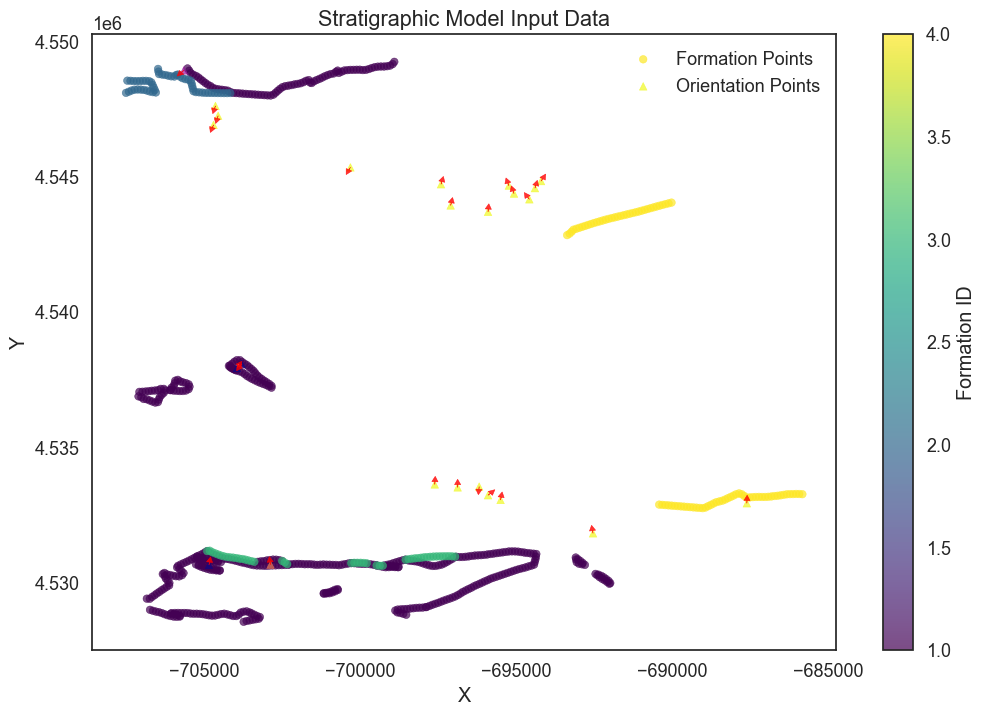

In [168]:
# Plot the points from gdf3
fig, ax = plt.subplots(figsize=(12, 8))

# Plot the points
scatter1 = ax.scatter(points_incl_topo_all_df['X'], points_incl_topo_all_df['Y'], 
           c=points_incl_topo_all_df['formation_id'], cmap='viridis', s=30, alpha=0.7, label='Formation Points')
scatter2 = ax.scatter(points_orientations_incl_topo_all_df['X'], points_orientations_incl_topo_all_df['Y'],
           c=points_orientations_incl_topo_all_df['formation_id'], cmap='plasma', s=30, alpha=0.7, label='Orientation Points', marker='^')


# Add arrows for azimuth where data is available
for idx, row in points_orientations_incl_topo_all_df.iterrows():
    if pd.notna(row['azimuth']) and pd.notna(row['dip']):
        # Arrow parameters
        arrow_length = 100  # arrow length in map units
        azimuth_rad = np.deg2rad(row['azimuth'])  # Convert azimuth to radians
        dx = arrow_length * np.sin(azimuth_rad)
        dy = arrow_length * np.cos(azimuth_rad)
        
        # Draw arrow
        ax.arrow(row['X'], row['Y'], dx, dy,
                head_width=200, head_length=200, fc='red', ec='red', alpha=0.8)
        

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_title('Stratigraphic Model Input Data')
ax.legend()
plt.colorbar(scatter1, ax=ax, orientation='vertical', label='Formation ID')
plt.show()

Active grids: GridTypes.NONE|TOPOGRAPHY|DENSE
Setting Backend To: AvailableBackends.numpy
Chunking done: 426 chunks


c:\Users\mrcon\miniconda3\envs\myenv\lib\site-packages\gempy_engine\modules\activator\_soft_segment.py:95: RuntimeWarning: overflow encountered in exp
  return 1.0 / (1.0 + bt.t.exp(x))


Chunking done: 8 chunks
Chunking done: 6 chunks
Chunking done: 36 chunks
Chunking done: 30 chunks
Creating cross section...


c:\Users\mrcon\miniconda3\envs\myenv\lib\site-packages\gempy_viewer\API\_plot_2d_API.py:176: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  p.fig.show()


Cross section created!


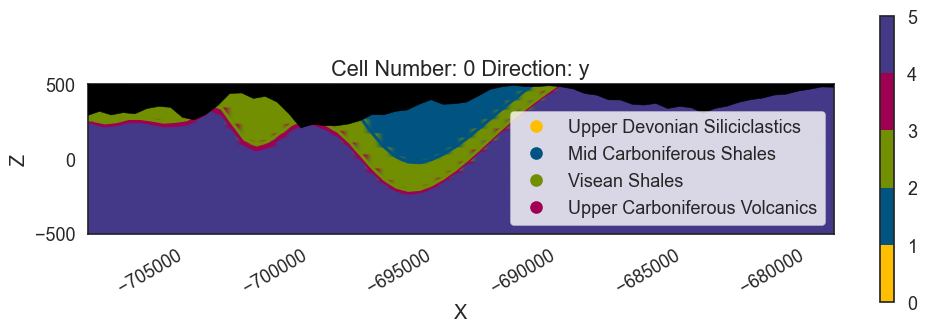

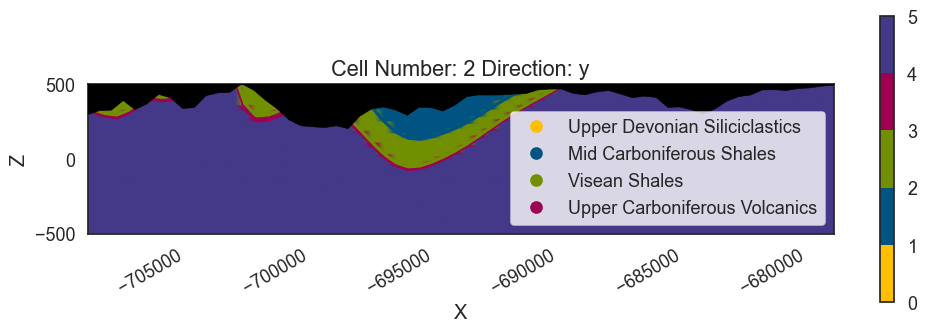

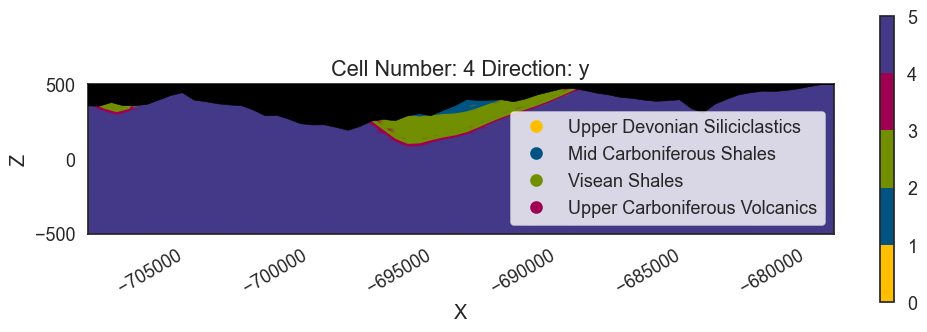

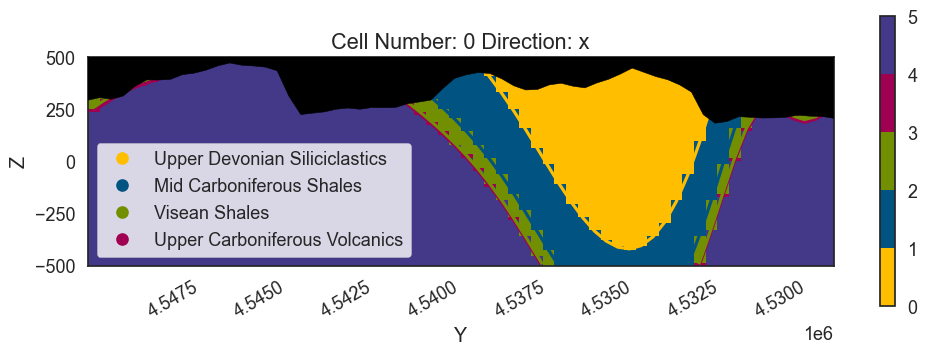

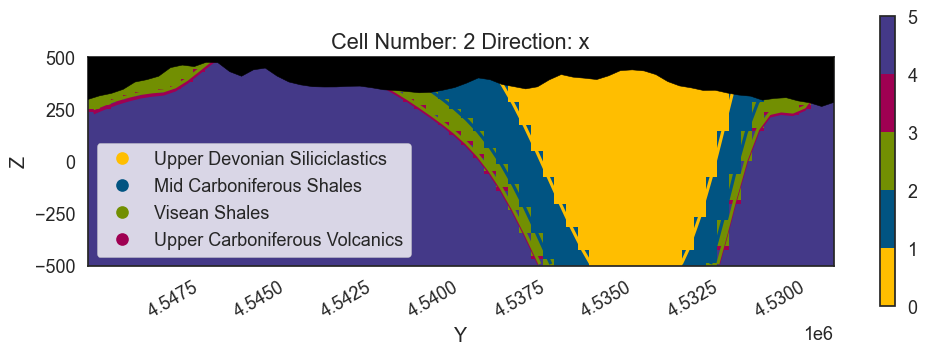

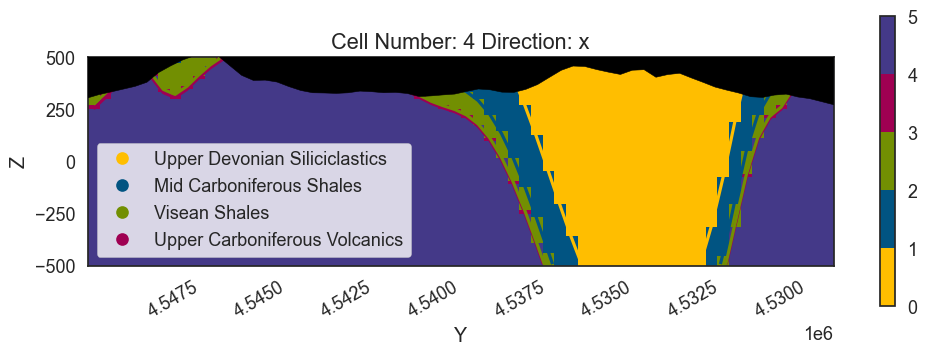

In [169]:
import gempy as gp
import numpy as np
import threading
import gempy as gp
import gempy_engine
import os
import pandas as pd
import HelperMethods
import gempy_viewer as gpv
from gempy_engine.core.data.stack_relation_type import StackRelationType

BASE_DIR = os.getcwd()
data_dir = os.path.join(BASE_DIR, '..', 'Data', 'Tharsis AOI 1')

# 1. Initialize model
top_right = (-678192, 4549947)
bottom_right = (-677518, 4529455)
bottom_left = (-706792, 4528453)
top_left = (-707522, 4548927)

# Calculate bounding box of the area of interest
path_to_data = r"C:\Users\mrcon\OneDrive\Data B\School\GP2\Internship\Mineye\GIS\Tharsis\Output\formationinputpoints.csv"
points_df = pd.read_csv(path_to_data, encoding='latin1', engine='python')
min_x = min(top_left[0], bottom_left[0])
max_x = max(top_right[0], bottom_right[0])
min_y = min(bottom_left[1], bottom_right[1])
max_y = max(top_left[1], top_right[1])
max_z = points_df['Z'].max()
nx = ny = nz = 64  # Define grid resolution
model_depth = -500

stratigraphic_geo_model = gp.create_geomodel(
    project_name='AOI',
    extent=[min_x, max_x, max_y, min_y, model_depth, max_z],
    # refinement=6,
    resolution=[nx, ny, nz],
    importer_helper=gp.data.ImporterHelper(
        path_to_orientations=os.path.join(BASE_DIR, "points_orientations_incl_topo_all_df.csv"),
        path_to_surface_points=os.path.join(BASE_DIR, "points_incl_topo_all_df.csv"),
    )
)

gp.map_stack_to_surfaces(
    gempy_model=stratigraphic_geo_model,
    mapping_object={
        "Strat_Series1": ("Upper Carboniferous Volcanics","Mid Carboniferous Shales", "Visean Shales", "Upper Devonian Siliciclastics")
    }
)

path_to_topography_reduced = os.path.join(data_dir, 'topo_reduced_sf0.1.tif')
gp.set_topography_from_file(grid=stratigraphic_geo_model.grid, filepath=path_to_topography_reduced)

gempy_model = gp.compute_model(stratigraphic_geo_model)

threading.Thread(target=HelperMethods.plot_3d_async, args=(stratigraphic_geo_model,)).start()
trigger_create_cross_section = True
if trigger_create_cross_section:
    print("Creating cross section...")
    HelperMethods.create_cross_section(stratigraphic_geo_model, cross_section=5)
    print("Cross section created!")
else:
    print("Cross section creation is disabled")

In [118]:
stratigraphic_geo_model.structural_frame

StructuralFrame(
	structural_groups=[
StructuralGroup(
	name=Strat_Series1,
	structural_relation=StackRelationType.ERODE,
	elements=[
Element(
	name=Upper Devonian Siliciclastics,
	color=#ffbe00,
	is_active=True
),
Element(
	name=Mid Carboniferous Shales,
	color=#015482,
	is_active=True
),
Element(
	name=Visean Shales,
	color=#728f02,
	is_active=True
),
Element(
	name=Upper Carboniferous Volcanics,
	color=#9f0052,
	is_active=True
)
]
)
],
	fault_relations=
[[False]],

# Inserting Plutonic Model Into Stratigraphic Model

In [170]:
import numpy as np

# 1. Get the formation IDs for the model
# The interpolated grid of formation IDs is stored here
lith_block = stratigraphic_geo_model.solutions.raw_arrays.lith_block
lith_block_reshaped = lith_block.reshape(64,64,64)

# 4. Get the coordinates of these voxels
voxel_coords = stratigraphic_geo_model.grid.regular_grid.values
voxel_coords_reshaped = voxel_coords.reshape(64, 64, 64, 3)

# Flip Y coordinate
# Flip Y to match input data range
y_min, y_max = np.min(voxel_coords[:, 1]), np.max(voxel_coords[:, 1])
voxel_coords_flipped = voxel_coords.copy()
voxel_coords_flipped[:, 1] = y_max - (voxel_coords[:, 1] - y_min)



# Find which formations are present in each voxel of the stratigraphic model
# 1 = Upper Carboniferous Volcanics
# 2 = Mid Carboniferous Shales
# 3 = Visean Shales
# 4 = Upper Devonian Siliciclastics

# Insert the igneous rock locations into the stratigraphic model
lith_block_reshaped[plutonite_mask] = 6
lith_block_modified = lith_block_reshaped.flatten()

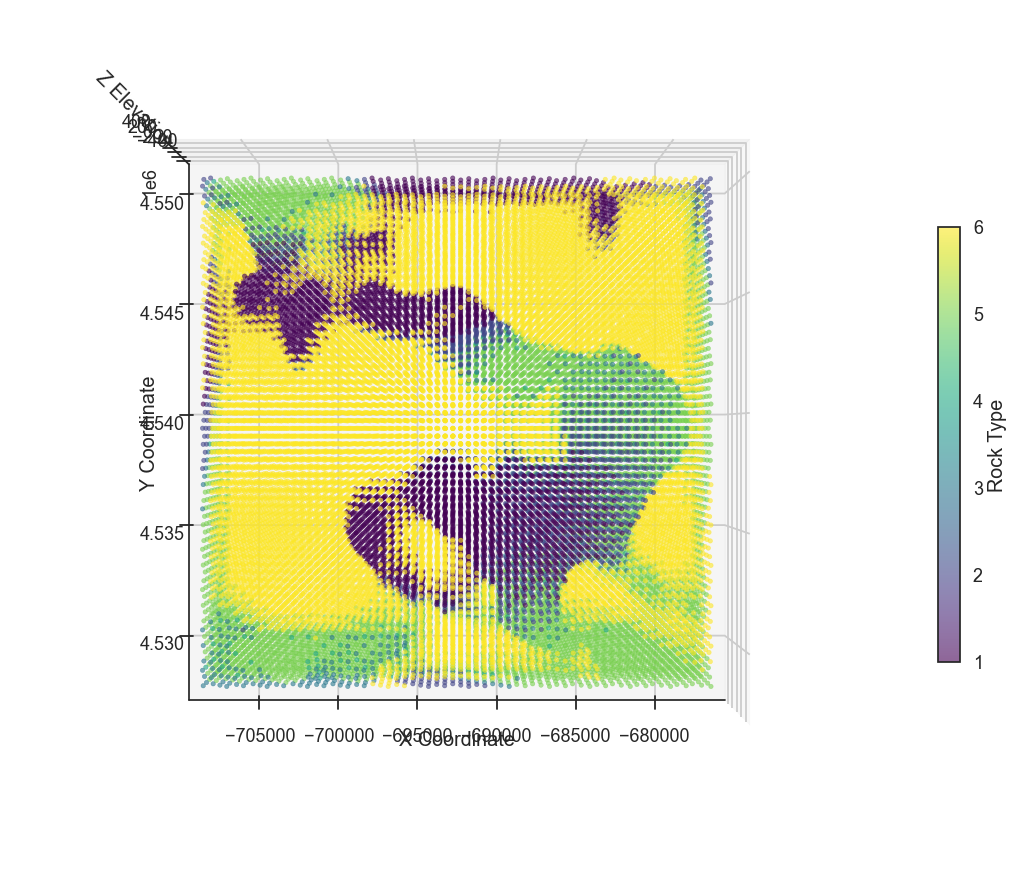

In [171]:
# Sample the plutonite coordinates for better performance
sample_step = 10  # Take every 10th point

# Create interactive 3D plot
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

# Create the scatter plot with color mapping based on Z values
scatter = ax.scatter(voxel_coords_flipped[:,0][::sample_step], 
                    voxel_coords_flipped[:,1][::sample_step], 
                    voxel_coords_flipped[:,2][::sample_step],
                    c=lith_block_modified[::sample_step], 
                    cmap='viridis', 
                    s=10, 
                    alpha=0.6)

# Add colorbar
plt.colorbar(scatter, ax=ax, label='Rock Type', shrink=0.5)

# Set labels and title
ax.set_xlabel('X Coordinate')
ax.set_ylabel('Y Coordinate')
ax.set_zlabel('Z Elevation')

# Improve the view
ax.view_init(elev=90, azim=270)
plt.tight_layout()
plt.show()

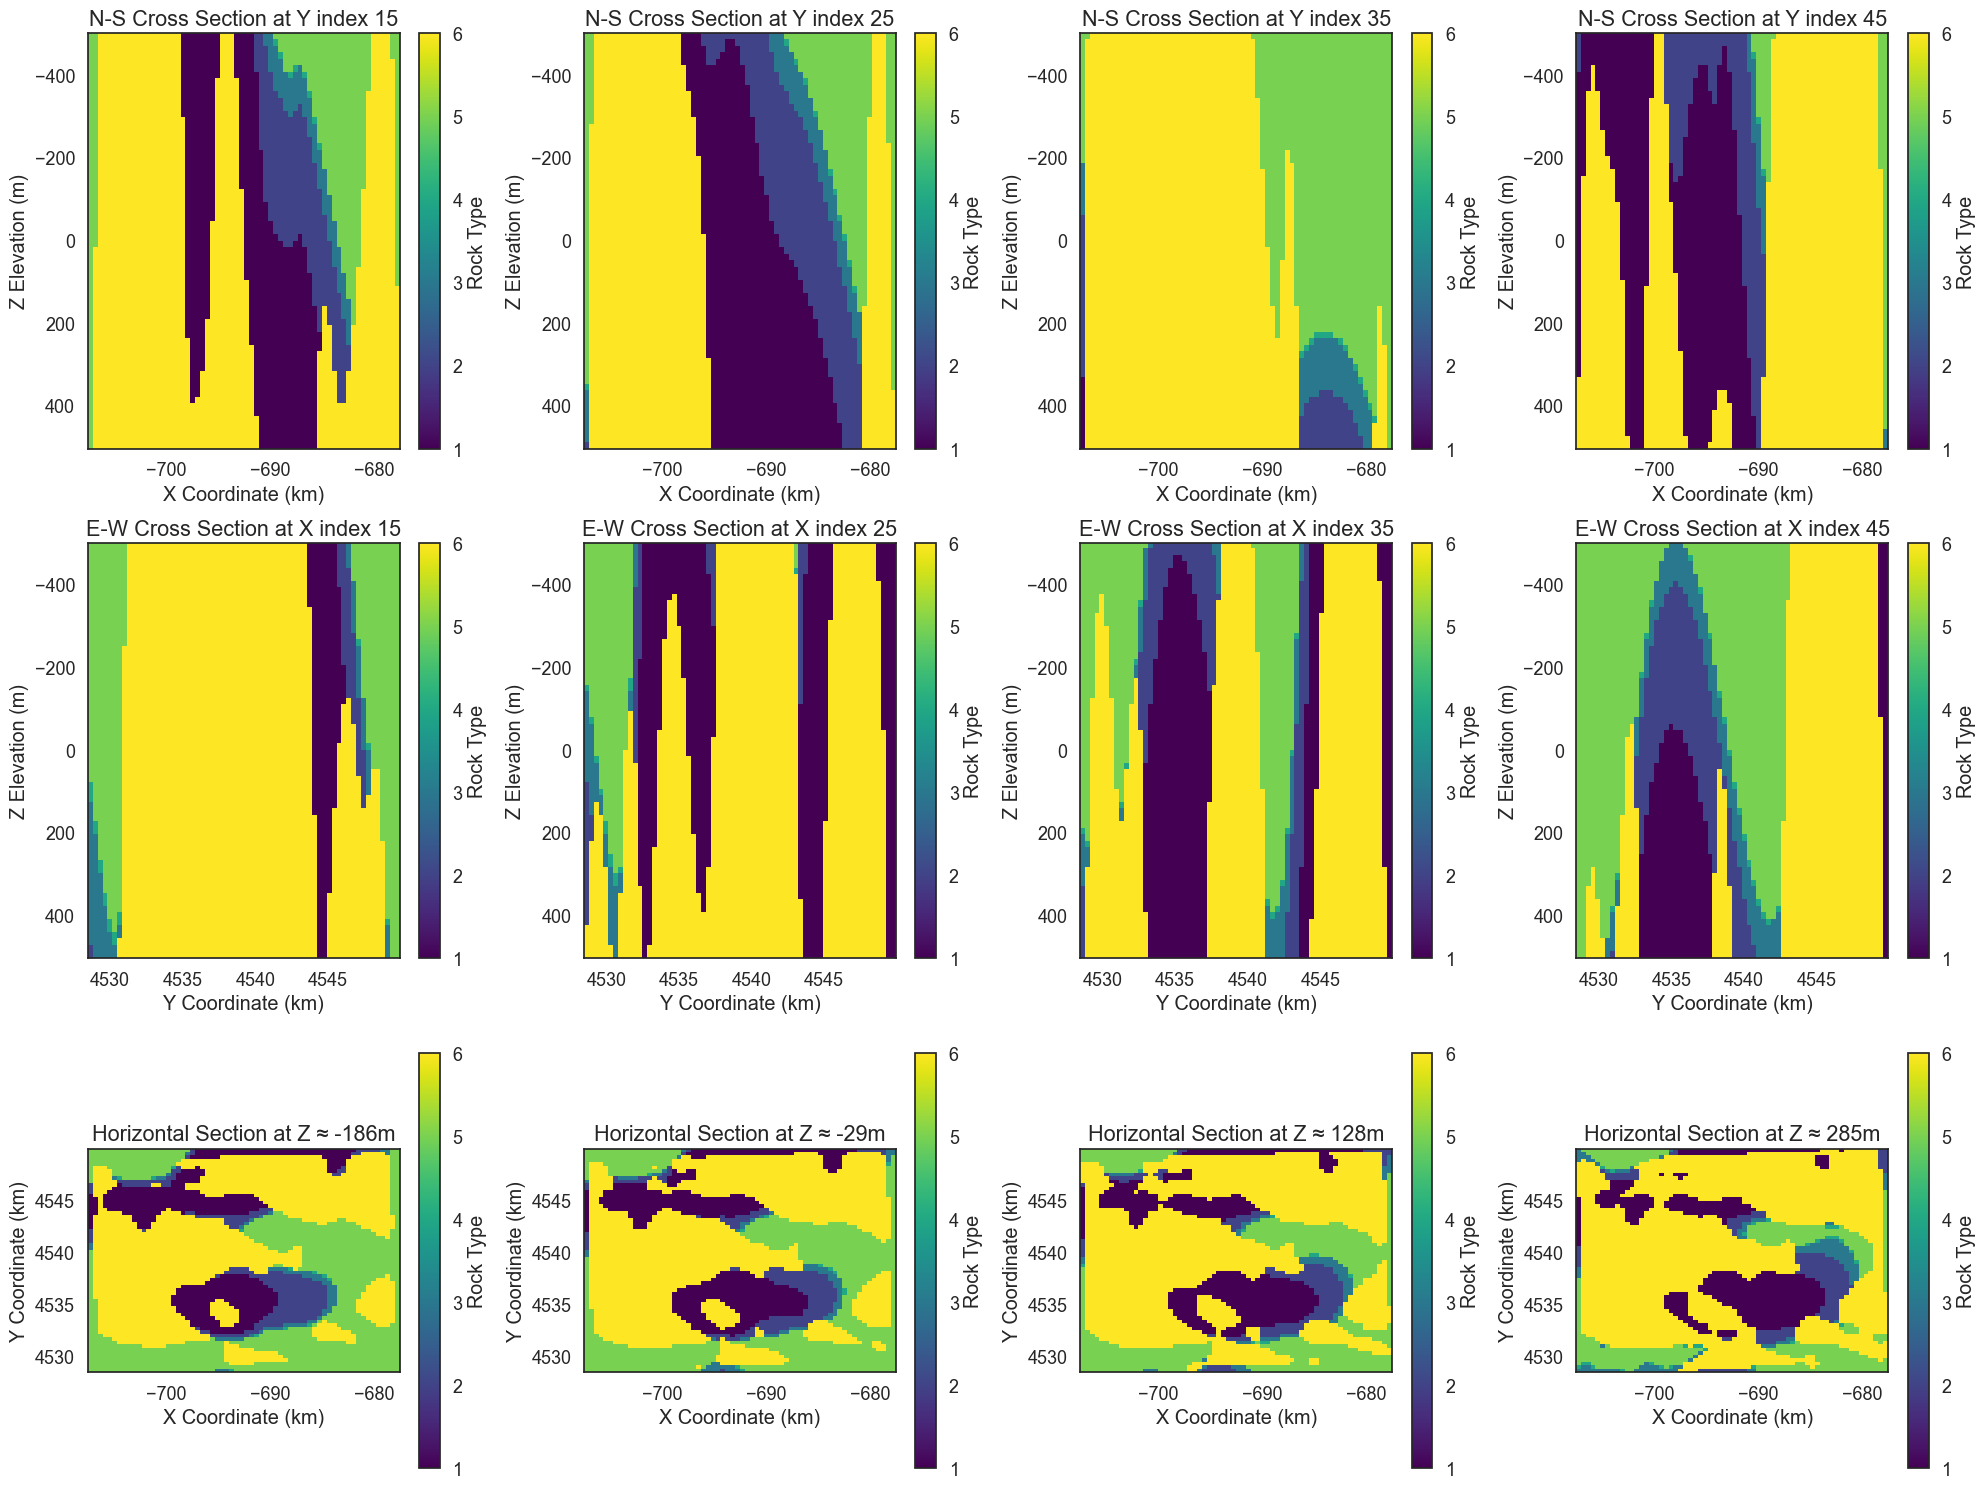

Rock Type Legend:
1: Upper Devonian Siliciclastics
2: Mid Carboniferous Shales
3: Visean Shales
4: Upper Carboniferous Volcanics
5: Basement
6: Tournaisian Plutonites (Intrusion)


In [172]:
# Create multiple cross sections of the combined model
fig, axes = plt.subplots(3, 4, figsize=(20, 15))

# North-South cross sections (XZ plane) at different Y positions
y_indices = [15, 25, 35, 45]  # Different Y positions
for i, y_idx in enumerate(y_indices):
    xz_slice = lith_block_modified.reshape(64, 64, 64)[:, y_idx, :]
    im = axes[0, i].imshow(xz_slice.T, cmap='viridis', origin='lower', 
                          extent=[min_x/1000, max_x/1000, model_depth, max_z], aspect='auto')
    axes[0, i].set_title(f'N-S Cross Section at Y index {y_idx}')
    axes[0, i].set_xlabel('X Coordinate (km)')
    axes[0, i].set_ylabel('Z Elevation (m)')
    axes[0, i].invert_yaxis()
    plt.colorbar(im, ax=axes[0, i], label='Rock Type')

# East-West cross sections (YZ plane) at different X positions
x_indices = [15, 25, 35, 45]  # Different X positions
for i, x_idx in enumerate(x_indices):
    yz_slice = lith_block_modified.reshape(64, 64, 64)[x_idx, :, :]
    im = axes[1, i].imshow(yz_slice.T, cmap='viridis', origin='lower',
                          extent=[min_y/1000, max_y/1000, model_depth, max_z], aspect='auto')
    axes[1, i].set_title(f'E-W Cross Section at X index {x_idx}')
    axes[1, i].set_xlabel('Y Coordinate (km)')
    axes[1, i].set_ylabel('Z Elevation (m)')
    axes[1, i].invert_yaxis()
    plt.colorbar(im, ax=axes[1, i], label='Rock Type')

# Horizontal cross sections (XY plane) at different Z elevations
z_indices = [20, 30, 40, 50]  # Different Z positions
for i, z_idx in enumerate(z_indices):
    xy_slice = lith_block_modified.reshape(64, 64, 64)[:, :, z_idx]
    im = axes[2, i].imshow(xy_slice.T, cmap='viridis', origin='lower',
                          extent=[min_x/1000, max_x/1000, min_y/1000, max_y/1000], aspect='equal')
    z_elevation = model_depth + (z_idx / 64) * (max_z - model_depth)
    axes[2, i].set_title(f'Horizontal Section at Z ≈ {z_elevation:.0f}m')
    axes[2, i].set_xlabel('X Coordinate (km)')
    axes[2, i].set_ylabel('Y Coordinate (km)')
    plt.colorbar(im, ax=axes[2, i], label='Rock Type')
    
plt.tight_layout()
plt.show()

# Add legend for rock types
print("Rock Type Legend:")
print("1: Upper Devonian Siliciclastics")
print("2: Mid Carboniferous Shales") 
print("3: Visean Shales")
print("4: Upper Carboniferous Volcanics")
print("5: Basement")
print("6: Tournaisian Plutonites (Intrusion)")